# 2.1. GIẢI THUẬT 1: CÂY QUYẾT ĐỊNH VÀ RỪNG CÂY 


## 2.1.2. Bài làm mẫu 


### Bài toán 1: Xây dựng cây quyết định và rừng cây với dữ liệu lấy từ 


#### Nhiệm vụ 1: Xây dựng cây quyết định bằng thư viện Scikit-Learn 



In [10]:
import os, sys, shutil, zipfile, json
from pathlib import Path
DATASET = "deceneu/default-of-credit-card-clients"
DATA_DIR = Path("data")
TARGET = Path("data.csv")

try:
    from kaggle.api.kaggle_api_extended import KaggleApi
except Exception:
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kaggle"])
    from kaggle.api.kaggle_api_extended import KaggleApi

#  Đặt biến môi trường Kaggle
os.environ["KAGGLE_CONFIG_DIR"] = r"C:\Users\Admin\.kaggle"

#  Kiểm tra kaggle.json tồn tại
config_path = Path(os.environ["KAGGLE_CONFIG_DIR"]) / "kaggle.json"
if not config_path.exists():
    raise FileNotFoundError("⚠️ Không tìm thấy kaggle.json tại C:\\Users\\Admin\\.kaggle\\kaggle.json")

#  Xác thực API
api = KaggleApi()
api.authenticate()

#  Nếu đã có data.csv thì bỏ qua
if TARGET.exists():
    print("✅ Đã có data.csv — bỏ qua tải.")
else:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print("⏬ Đang tải dataset từ Kaggle...")
    api.dataset_download_files(dataset=DATASET, path=str(DATA_DIR), unzip=True)
    print("✅ Giải nén hoàn tất!")

    #  Tìm file CSV thực tế trong thư mục data/
    csv_files = [f for f in DATA_DIR.glob("*.csv")]
    if not csv_files:
        raise FileNotFoundError("Không tìm thấy file .csv trong thư mục data/ sau khi tải.")
    else:
        # Tìm file có tên giống nhất (Kaggle file hiện tại là default_of_credit_card_clients.csv)
        src = None
        for f in csv_files:
            if "credit" in f.name.lower():
                src = f
                break
        if src is None:
            src = csv_files[0]

        shutil.copy2(src, TARGET)
        print(f"Đã tạo {TARGET} từ {src.name} — cho bài Decision Tree")


✅ Đã có data.csv — bỏ qua tải.


In [2]:
import numpy as np #numerical computation 
import pandas as pd #data wrangling 
import matplotlib.pyplot as plt #plotting package 
#Next line helps with rendering plots 
%matplotlib inline 
import matplotlib as mpl #add'l plotting functionality 
mpl.rcParams['figure.dpi'] = 400 #high res figures 
import graphviz #to visualize decision trees
import sys

%pip install -U scikit-learn graphviz



Note: you may need to restart the kernel to use updated packages.


In [ ]:
df = pd.read_csv('data.csv')  

features_response = df.columns.tolist()
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3',
                   'PAY_4', 'PAY_5', 'PAY_6',
                   'EDUCATION_CAT', 'graduate school',
                   'high school', 'none',
                   'others', 'university']
features_response = [item for item in features_response if item not in items_to_remove]
features_response


['LIMIT_BAL',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [4]:
from sklearn.model_selection import train_test_split 
from sklearn import tree 

X_train, X_test, y_train, y_test = \
    train_test_split(df[features_response[:-1]].values,
                     df['default payment next month'].values,
                     test_size=0.2, random_state=24)
 

In [5]:
dt = tree.DecisionTreeClassifier(max_depth=2)
dt.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


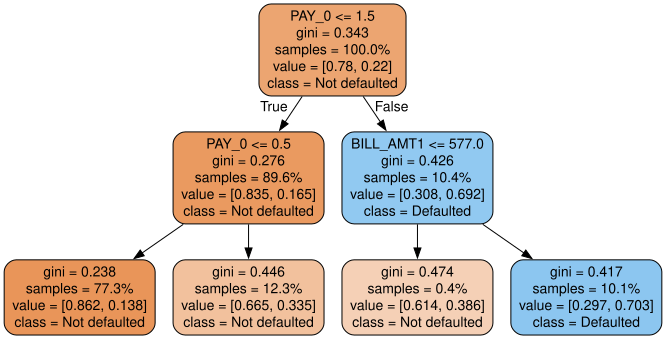

In [8]:
dot_data = tree.export_graphviz(dt,
    out_file=None,
    filled=True,
    rounded=True,
    feature_names=features_response[:-1],
    proportion=True,
    class_names=['Not defaulted', 'Defaulted'])
graph = graphviz.Source(dot_data)
graph  # hiển thị cây



#### Nhiệm vụ 2: Tìm tham số tối ưu cho cây quyết định bằng GridSearchCV và vẽ biểu đồ đánh giá mô hình với các tham số khác nhau  


Fitting 4 folds for each of 7 candidates, totalling 28 fits


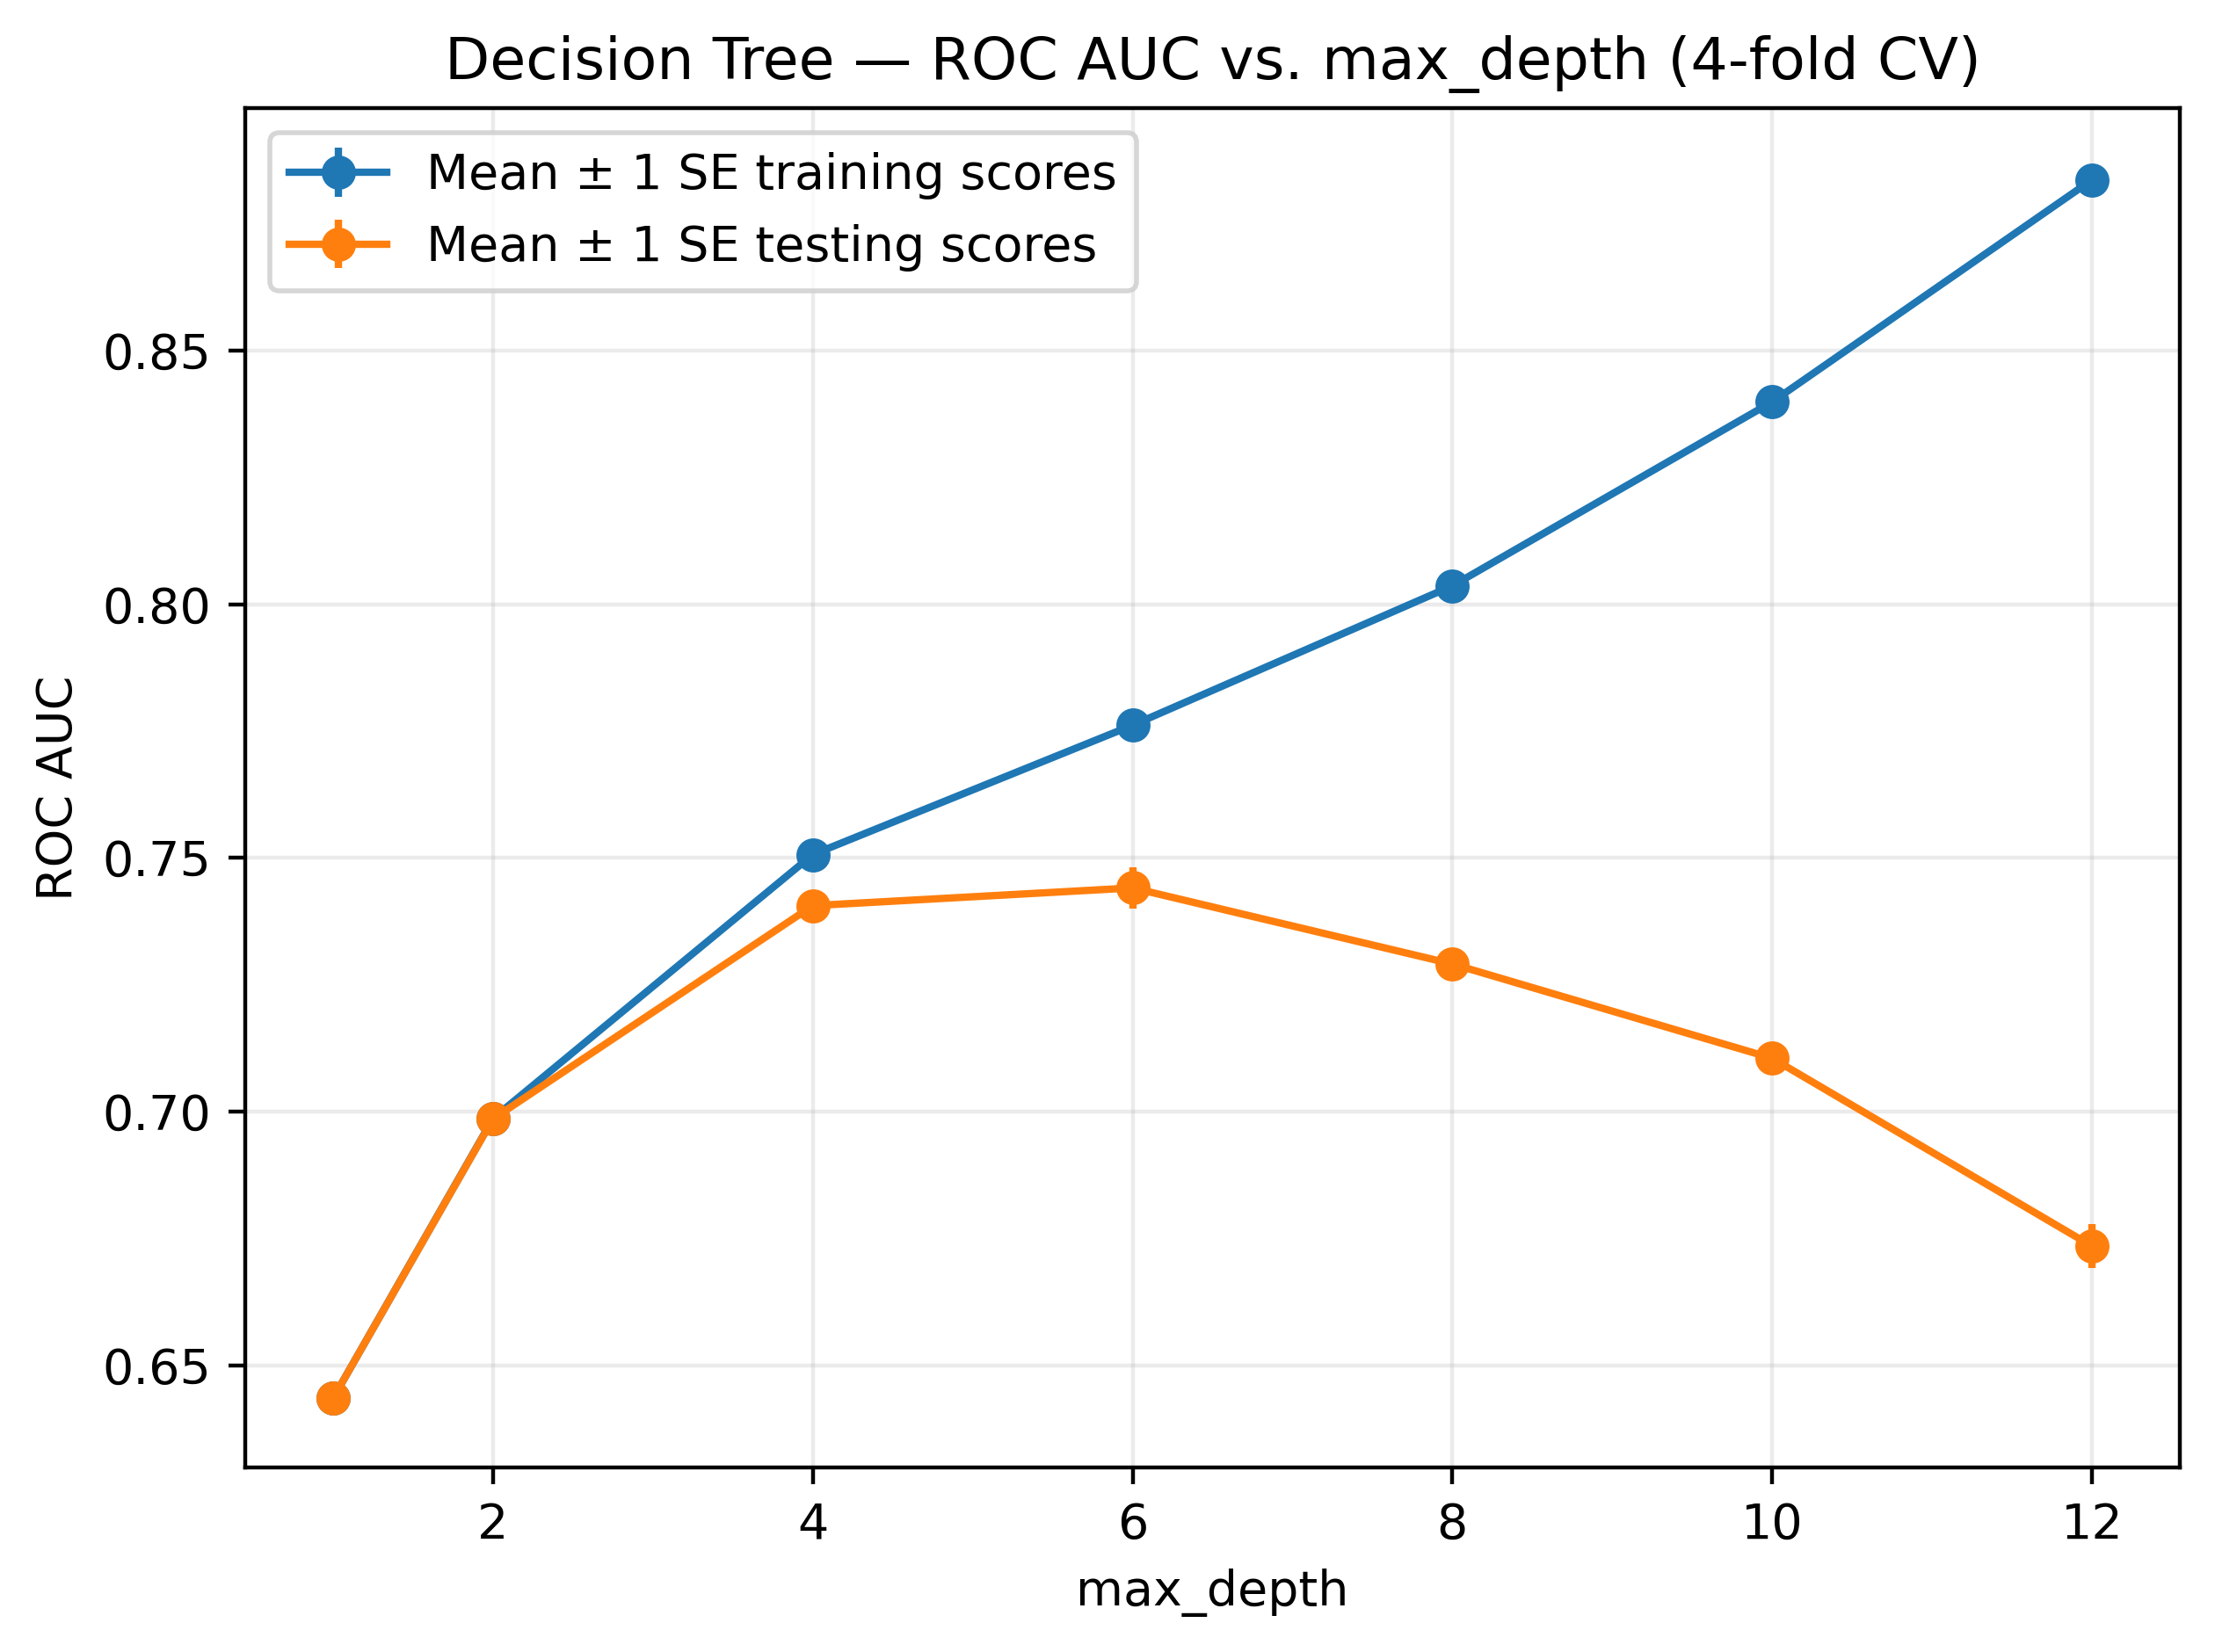

Biểu đồ đã lưu: dt_gridsearch_roc_auc.png


In [ ]:
from sklearn.model_selection import GridSearchCV


params = {'max_depth':[1, 2, 4, 6, 8, 10, 12]}  # parameters
dt = tree.DecisionTreeClassifier(random_state=24)  # tree model

cv = GridSearchCV(
    dt,
    param_grid=params,
    scoring='roc_auc',
    n_jobs=None,
    refit=True,
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True
)  # cv.best_estimator

cv.fit(X_train, y_train)


cv_results_df = pd.DataFrame(cv.cv_results_)
# Nếu cột param_max_depth là object -> ép sang int để vẽ trơn tru
try:
    x_depth = cv_results_df['param_max_depth'].astype(int)
except Exception:
    x_depth = cv_results_df['param_max_depth']

ax = plt.axes()
ax.errorbar(
    x_depth,
    cv_results_df['mean_train_score'],
    yerr=cv_results_df['std_train_score'] / np.sqrt(4),
    label='Mean ± 1 SE training scores',
    marker='o'
)
ax.errorbar(
    x_depth,
    cv_results_df['mean_test_score'],
    yerr=cv_results_df['std_test_score'] / np.sqrt(4),
    label='Mean ± 1 SE testing scores',
    marker='o'
)
ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.title('Decision Tree — ROC AUC vs. max_depth (4-fold CV)')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("dt_gridsearch_roc_auc.png", dpi=300)
plt.show()

print("Biểu đồ đã lưu: dt_gridsearch_roc_auc.png")



#### Nhiệm vụ 3: Xây dựng rừng cây (random forest)


In [19]:
from sklearn.model_selection import GridSearchCV 
from sklearn.ensemble import RandomForestClassifier 
rf = RandomForestClassifier(
    n_estimators=10, criterion='gini', max_depth=3,
    min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
    max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0,
    bootstrap=True, oob_score=False, n_jobs=None,
    random_state=4, verbose=0, warm_start=False, class_weight=None)

In [22]:
#a parameter grid for this exercise in order to search the numbers of trees, ranging from 10 to 100 by 10s 
rf_params_ex = {'n_estimators':list(range(10,110,10))} 
cv_rf_ex = GridSearchCV(rf, param_grid=rf_params_ex, 
                        scoring='roc_auc', n_jobs=None, 
                        refit=True, cv=4, verbose=1, 
                        error_score=np.nan, return_train_score=True) 
cv_rf_ex.fit(X_train, y_train) 

Fitting 4 folds for each of 10 candidates, totalling 40 fits


,estimator,RandomForestC...andom_state=4)
,param_grid,"{'n_estimators': [10, 20, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,60


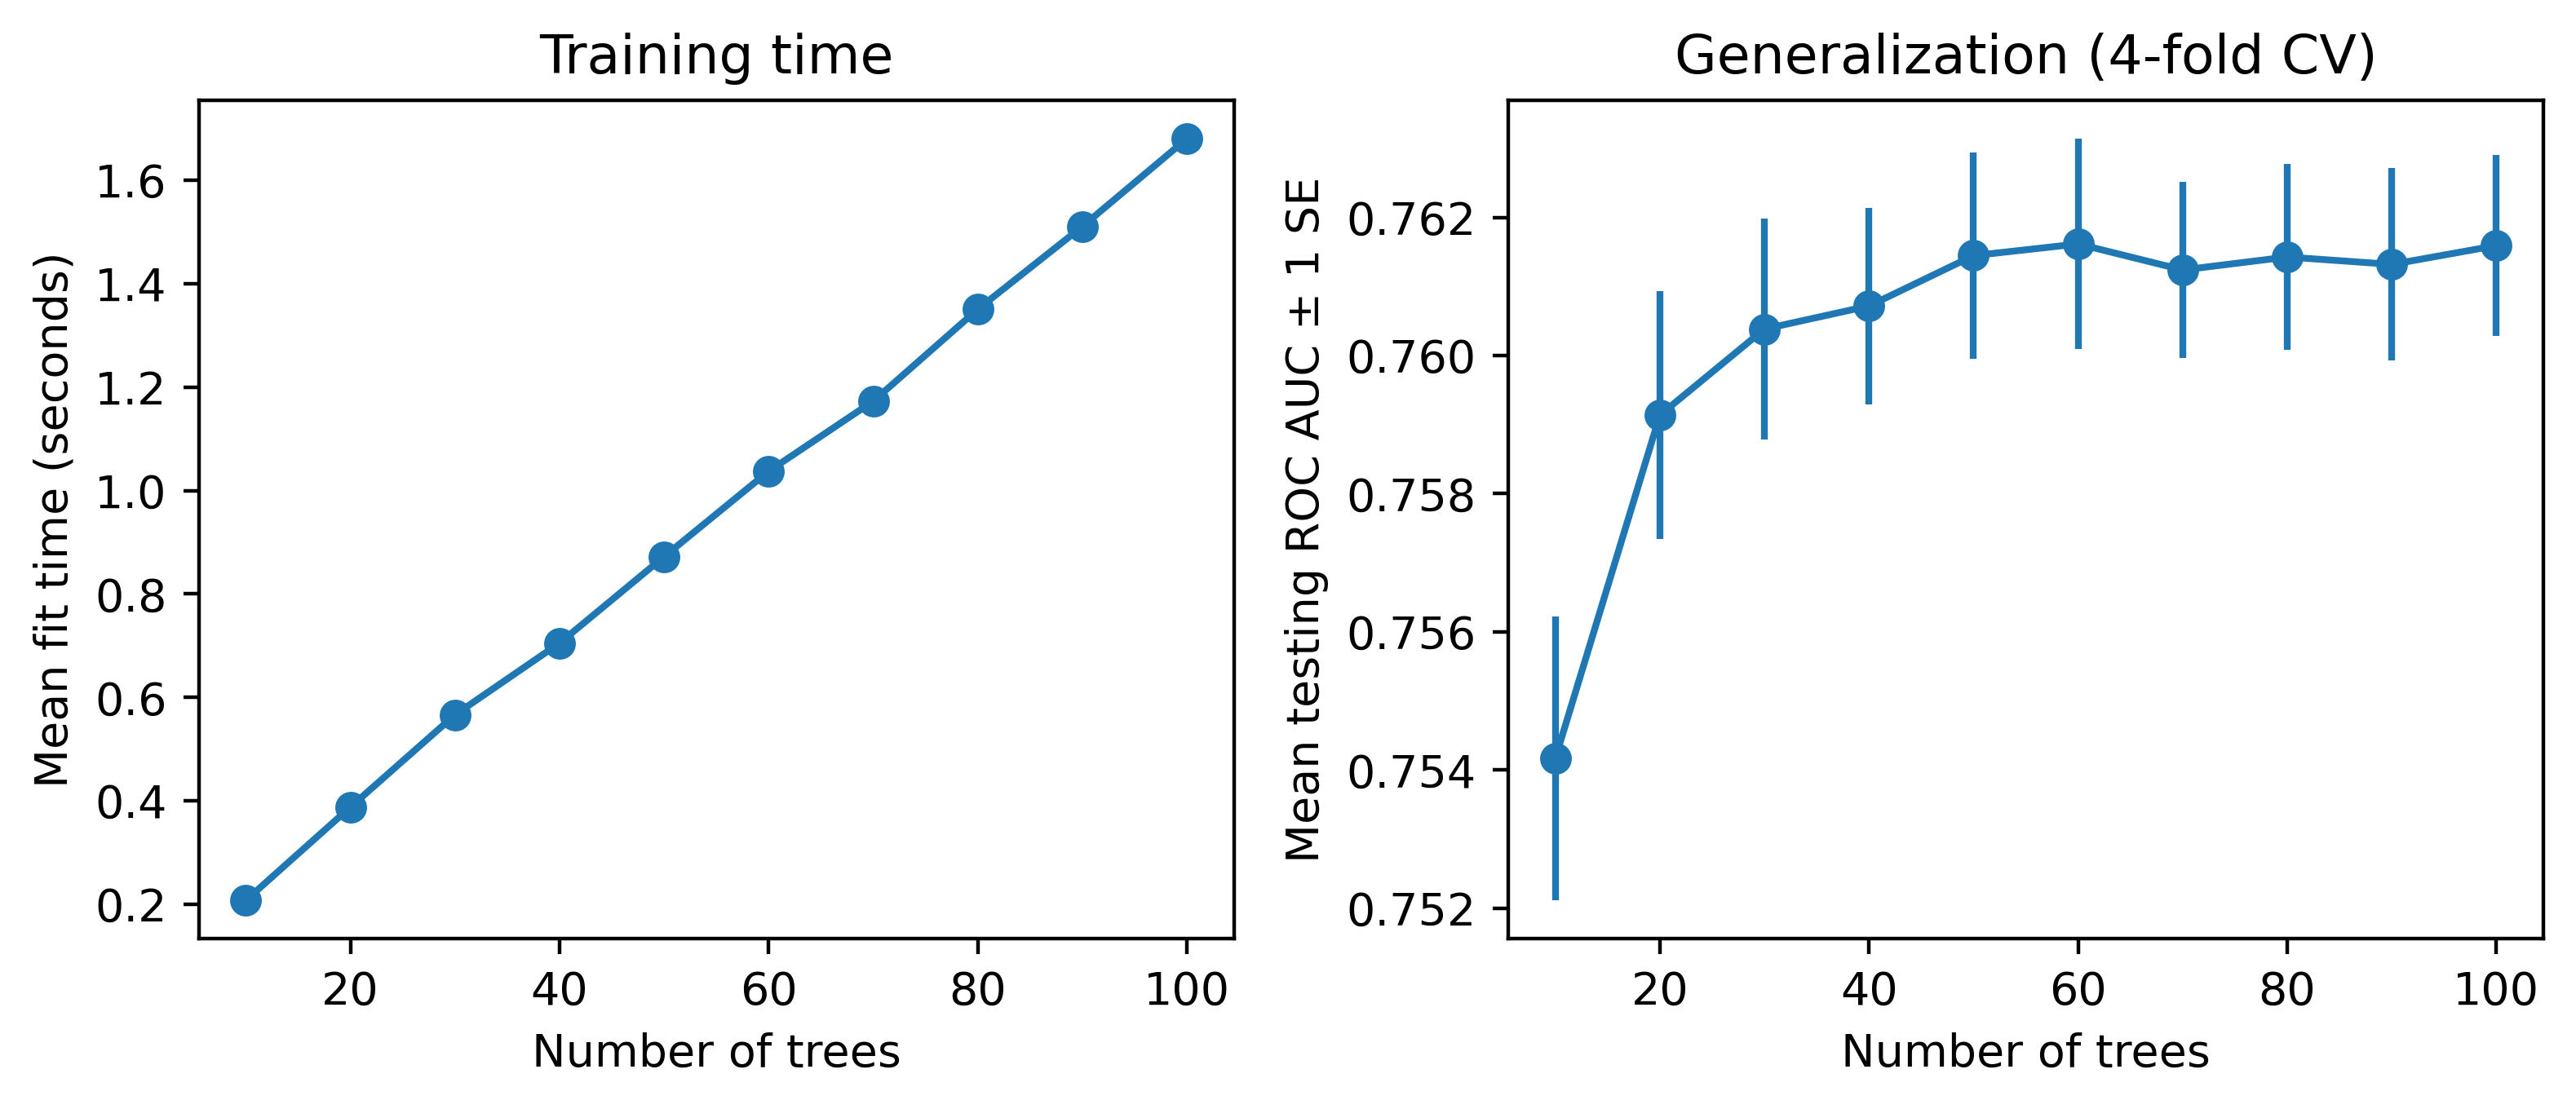

Đã lưu biểu đồ: rf_gridsearch_plots.png
Test ROC AUC (best_rf): 0.7655754234828034

Classification report (best_rf):
               precision    recall  f1-score   support

           0       0.82      0.97      0.89      4643
           1       0.72      0.27      0.39      1357

    accuracy                           0.81      6000
   macro avg       0.77      0.62      0.64      6000
weighted avg       0.80      0.81      0.77      6000



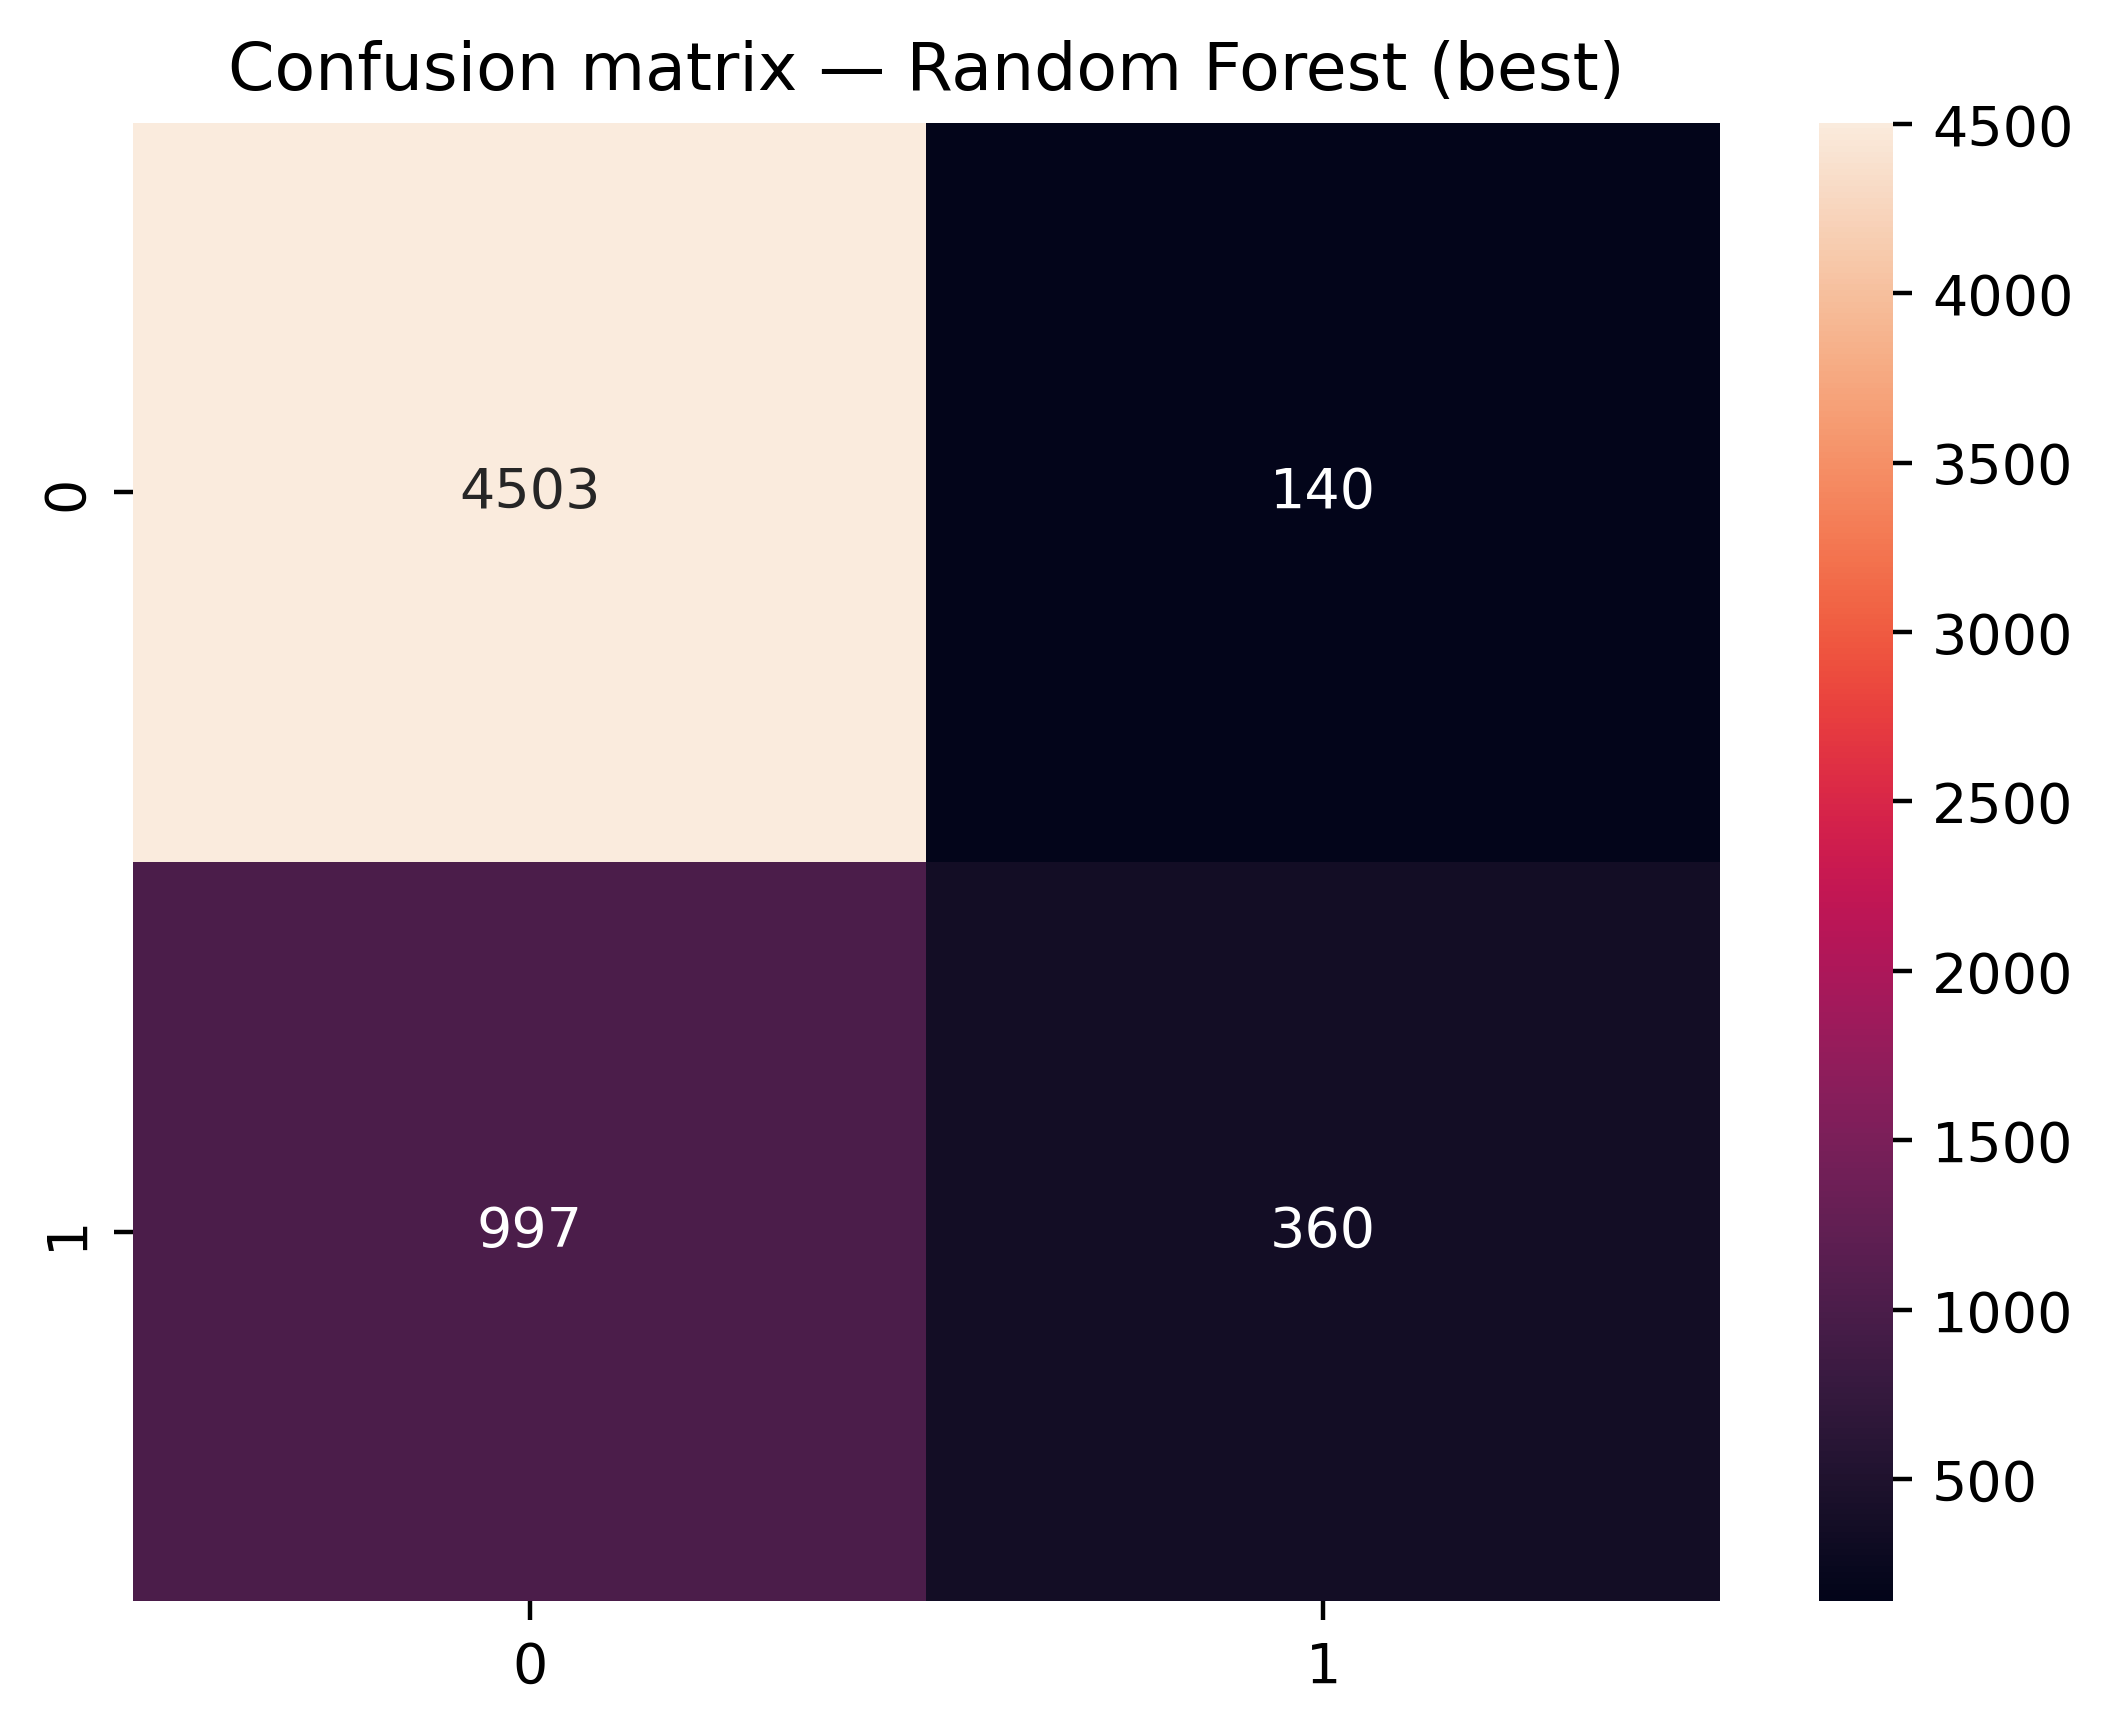

In [27]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
cv_rf_ex_results_df = pd.DataFrame(cv_rf_ex.cv_results_)
best_rf = cv_rf_ex.best_estimator_

try:
    x_trees = cv_rf_ex_results_df['param_n_estimators'].astype(int)
except Exception:
    x_trees = cv_rf_ex_results_df['param_n_estimators']

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 3.5))
axs[0].plot(x_trees, cv_rf_ex_results_df['mean_fit_time'], '-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[0].set_title('Training time')
axs[1].errorbar(
    x_trees,
    cv_rf_ex_results_df['mean_test_score'],
    yerr=cv_rf_ex_results_df['std_test_score'] / np.sqrt(4),
    fmt='-o'
)
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC ± 1 SE')
axs[1].set_title('Generalization (4-fold CV)')

plt.tight_layout()
plt.savefig("rf_gridsearch_plots.png", dpi=300)
plt.show()
print("Đã lưu biểu đồ: rf_gridsearch_plots.png")
y_proba_rf = best_rf.predict_proba(X_test)[:, 1]
y_pred_rf  = best_rf.predict(X_test)
print("Test ROC AUC (best_rf):", roc_auc_score(y_test, y_proba_rf))
print("\nClassification report (best_rf):\n", classification_report(y_test, y_pred_rf))
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion matrix — Random Forest (best)")
plt.show()

<Axes: >

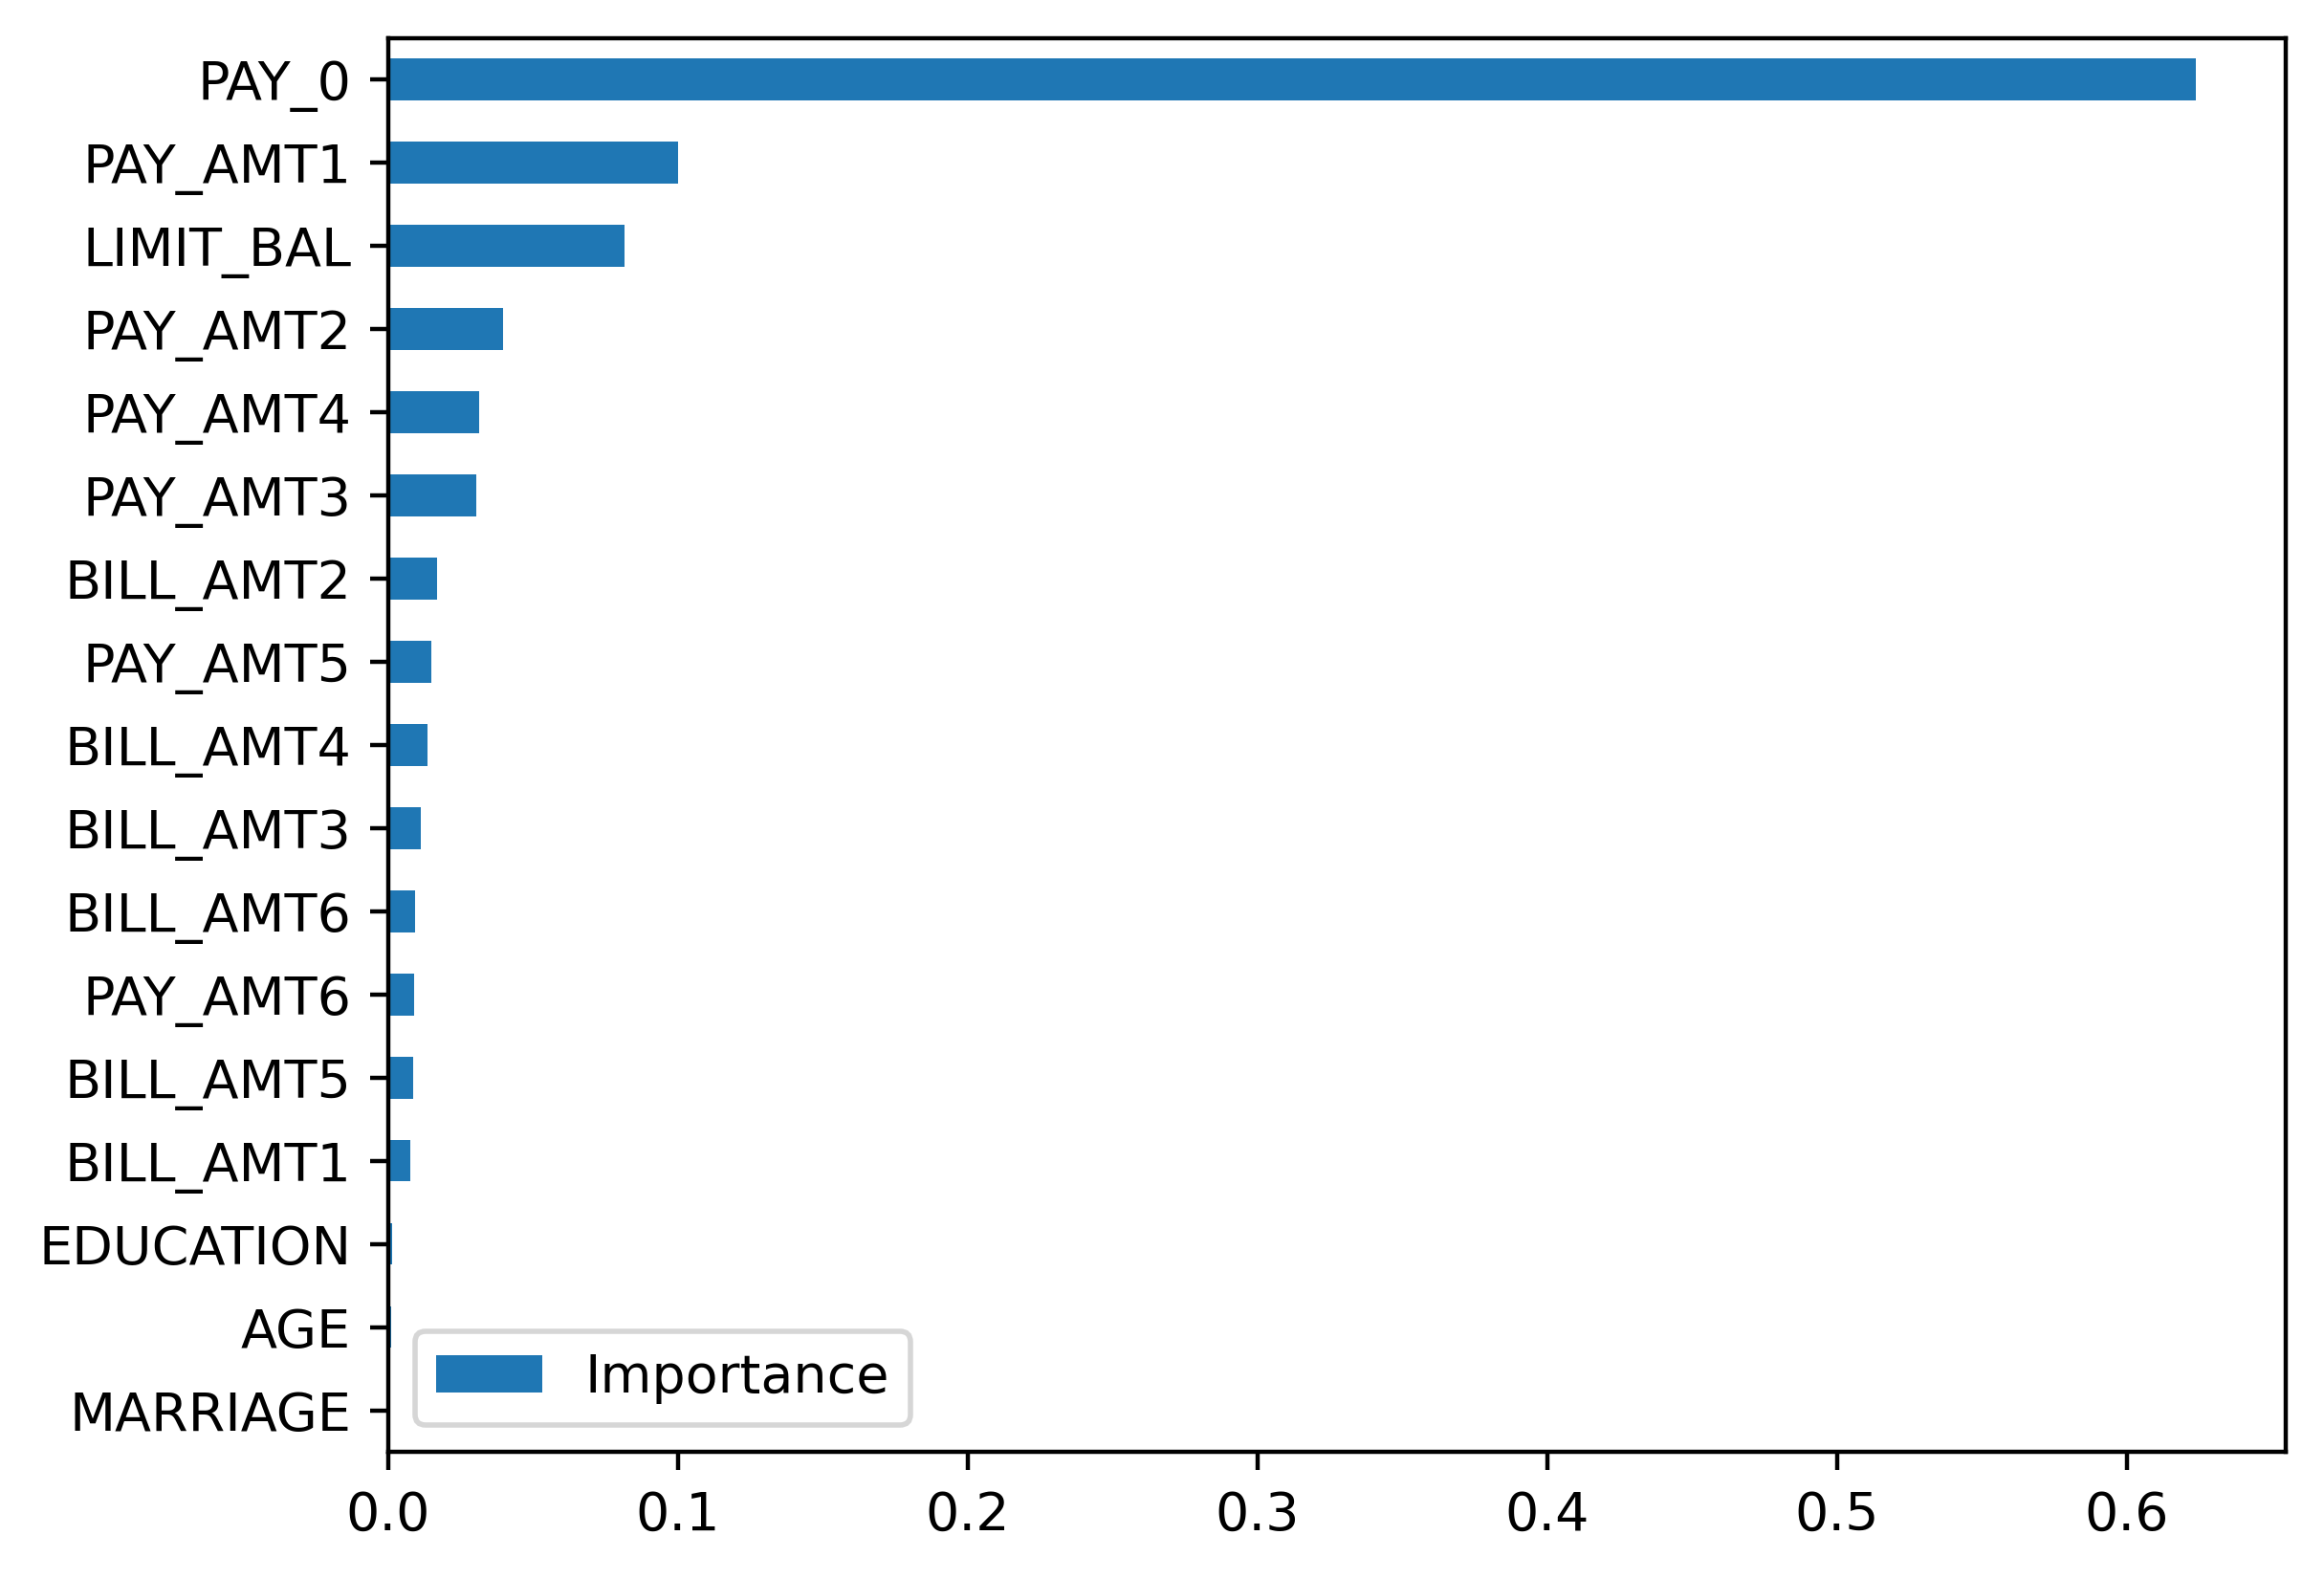

In [28]:
# {'n_estimators': 50}
cv_rf_ex.best_params_

# the feature names and importances
feat_imp_df = pd.DataFrame({
    'Importance': cv_rf_ex.best_estimator_.feature_importances_
}, index=features_response[:-1])

feat_imp_df.sort_values('Importance', ascending=True).plot.barh()


## 2.1.3. Bài tập thực hành 1 Xây dựng cây quyết định và rừng cây trên dữ liệu Titanic  


In [32]:

import os, json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import graphviz

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import seaborn as sns



In [33]:
DATASET_COMP = "titanic"
DATA_DIR_TI = Path("data_titanic")
TARGET_FILE_TI = Path("data_titanic.csv")
try:
    api
except NameError:
    from kaggle.api.kaggle_api_extended import KaggleApi
    import os
    os.environ["KAGGLE_CONFIG_DIR"] = r"C:\Users\Admin\.kaggle"
    api = KaggleApi()
    api.authenticate()

if not TARGET_FILE_TI.exists():
    DATA_DIR_TI.mkdir(parents=True, exist_ok=True)
    print(" Đang tải Titanic…")
    # Tải file zip Titanic từ Kaggle Competition
api.competition_download_files(DATASET_COMP, path=str(DATA_DIR_TI))
print(" Đã tải file zip Titanic.")

# Giải nén thủ công (vì Kaggle API không tự unzip)
import zipfile, glob
for z in glob.glob(str(DATA_DIR_TI / "*.zip")):
    with zipfile.ZipFile(z, "r") as zf:
        zf.extractall(DATA_DIR_TI)
    print(" Giải nén:", os.path.basename(z))
    # Competition Titanic có train.csv, test.csv. Ta dùng train.csv, đổi tên cho thống nhất.
    src_train = DATA_DIR_TI / "train.csv"
    assert src_train.exists(), "Không tìm thấy train.csv sau khi tải/unzip."
    shutil.copy2(src_train, TARGET_FILE_TI)
    print(f" Đã tạo {TARGET_FILE_TI.name} từ train.csv")
else:
    print(" Đã có data_titanic.csv — bỏ qua tải.")



 Đã tải file zip Titanic.
 Giải nén: titanic.zip
 Đã tạo data_titanic.csv từ train.csv
 Đã có data_titanic.csv — bỏ qua tải.


In [37]:
# --- 1) Nạp & tiền xử lý dữ liệu 
df_ti = pd.read_csv(TARGET_FILE_TI)
# Bỏ các cột text khó dùng trực tiếp
items_to_remove_ti = ['PassengerId', 'Name', 'Ticket', 'Cabin']

# Chuyển Sex, Embarked sang số; điền thiếu
df_ti['Sex'] = df_ti['Sex'].map({'male': 1, 'female': 0}).astype('Int64')
df_ti['Embarked'] = df_ti['Embarked'].fillna(df_ti['Embarked'].mode()[0])
df_ti['Embarked'] = df_ti['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype('Int64')
df_ti['Age'] = df_ti['Age'].fillna(df_ti['Age'].median())
df_ti['Fare'] = df_ti['Fare'].fillna(df_ti['Fare'].median())

# Tạo danh sách cột 
features_response_ti = [c for c in df_ti.columns if c not in items_to_remove_ti]

# Đảm bảo 'Survived' là cột cuối cùng trong danh sách 
features_response_ti = [c for c in features_response_ti if c != 'Survived'] + ['Survived']

# --- 2) Chia train/test 
X_train, X_test, y_train, y_test = train_test_split(
    df_ti[features_response_ti[:-1]].values,
    df_ti['Survived'].values,
    test_size=0.2,
    random_state=24,
    stratify=df_ti['Survived'].values
)

# --- 3) Decision Tree (độ sâu tối đa 2) ---
dt_ti = tree.DecisionTreeClassifier(max_depth=2, random_state=24)
dt_ti.fit(X_train, y_train)

# Vẽ cây bằng graphviz
dot_data_ti = tree.export_graphviz(
    dt_ti,
    out_file=None,
    filled=True,
    rounded=True,
    feature_names=features_response_ti[:-1],
    proportion=True,
    class_names=['Did not survive', 'Survived']
)
graph_ti = graphviz.Source(dot_data_ti)
# Hiển thị trong notebook:
graph_ti

# (tuỳ chọn) Lưu ảnh/PDF của cây 
graph_ti.render("titanic_decision_tree", format="png", cleanup=True, quiet=True)

# --- 4) GridSearchCV cho max_depth 
params_ti = {'max_depth': [1, 2, 4, 6, 8, 10, 12]}
cv_ti = GridSearchCV(
    tree.DecisionTreeClassifier(random_state=24),
    param_grid=params_ti,
    scoring='roc_auc',
    n_jobs=None,
    refit=True,
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True
)
cv_ti.fit(X_train, y_train)


Fitting 4 folds for each of 7 candidates, totalling 28 fits


,estimator,DecisionTreeC...ndom_state=24)
,param_grid,"{'max_depth': [1, 2, ...]}"
,scoring,'roc_auc'
,n_jobs,None
,refit,True
,cv,4
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,criterion,'gini'


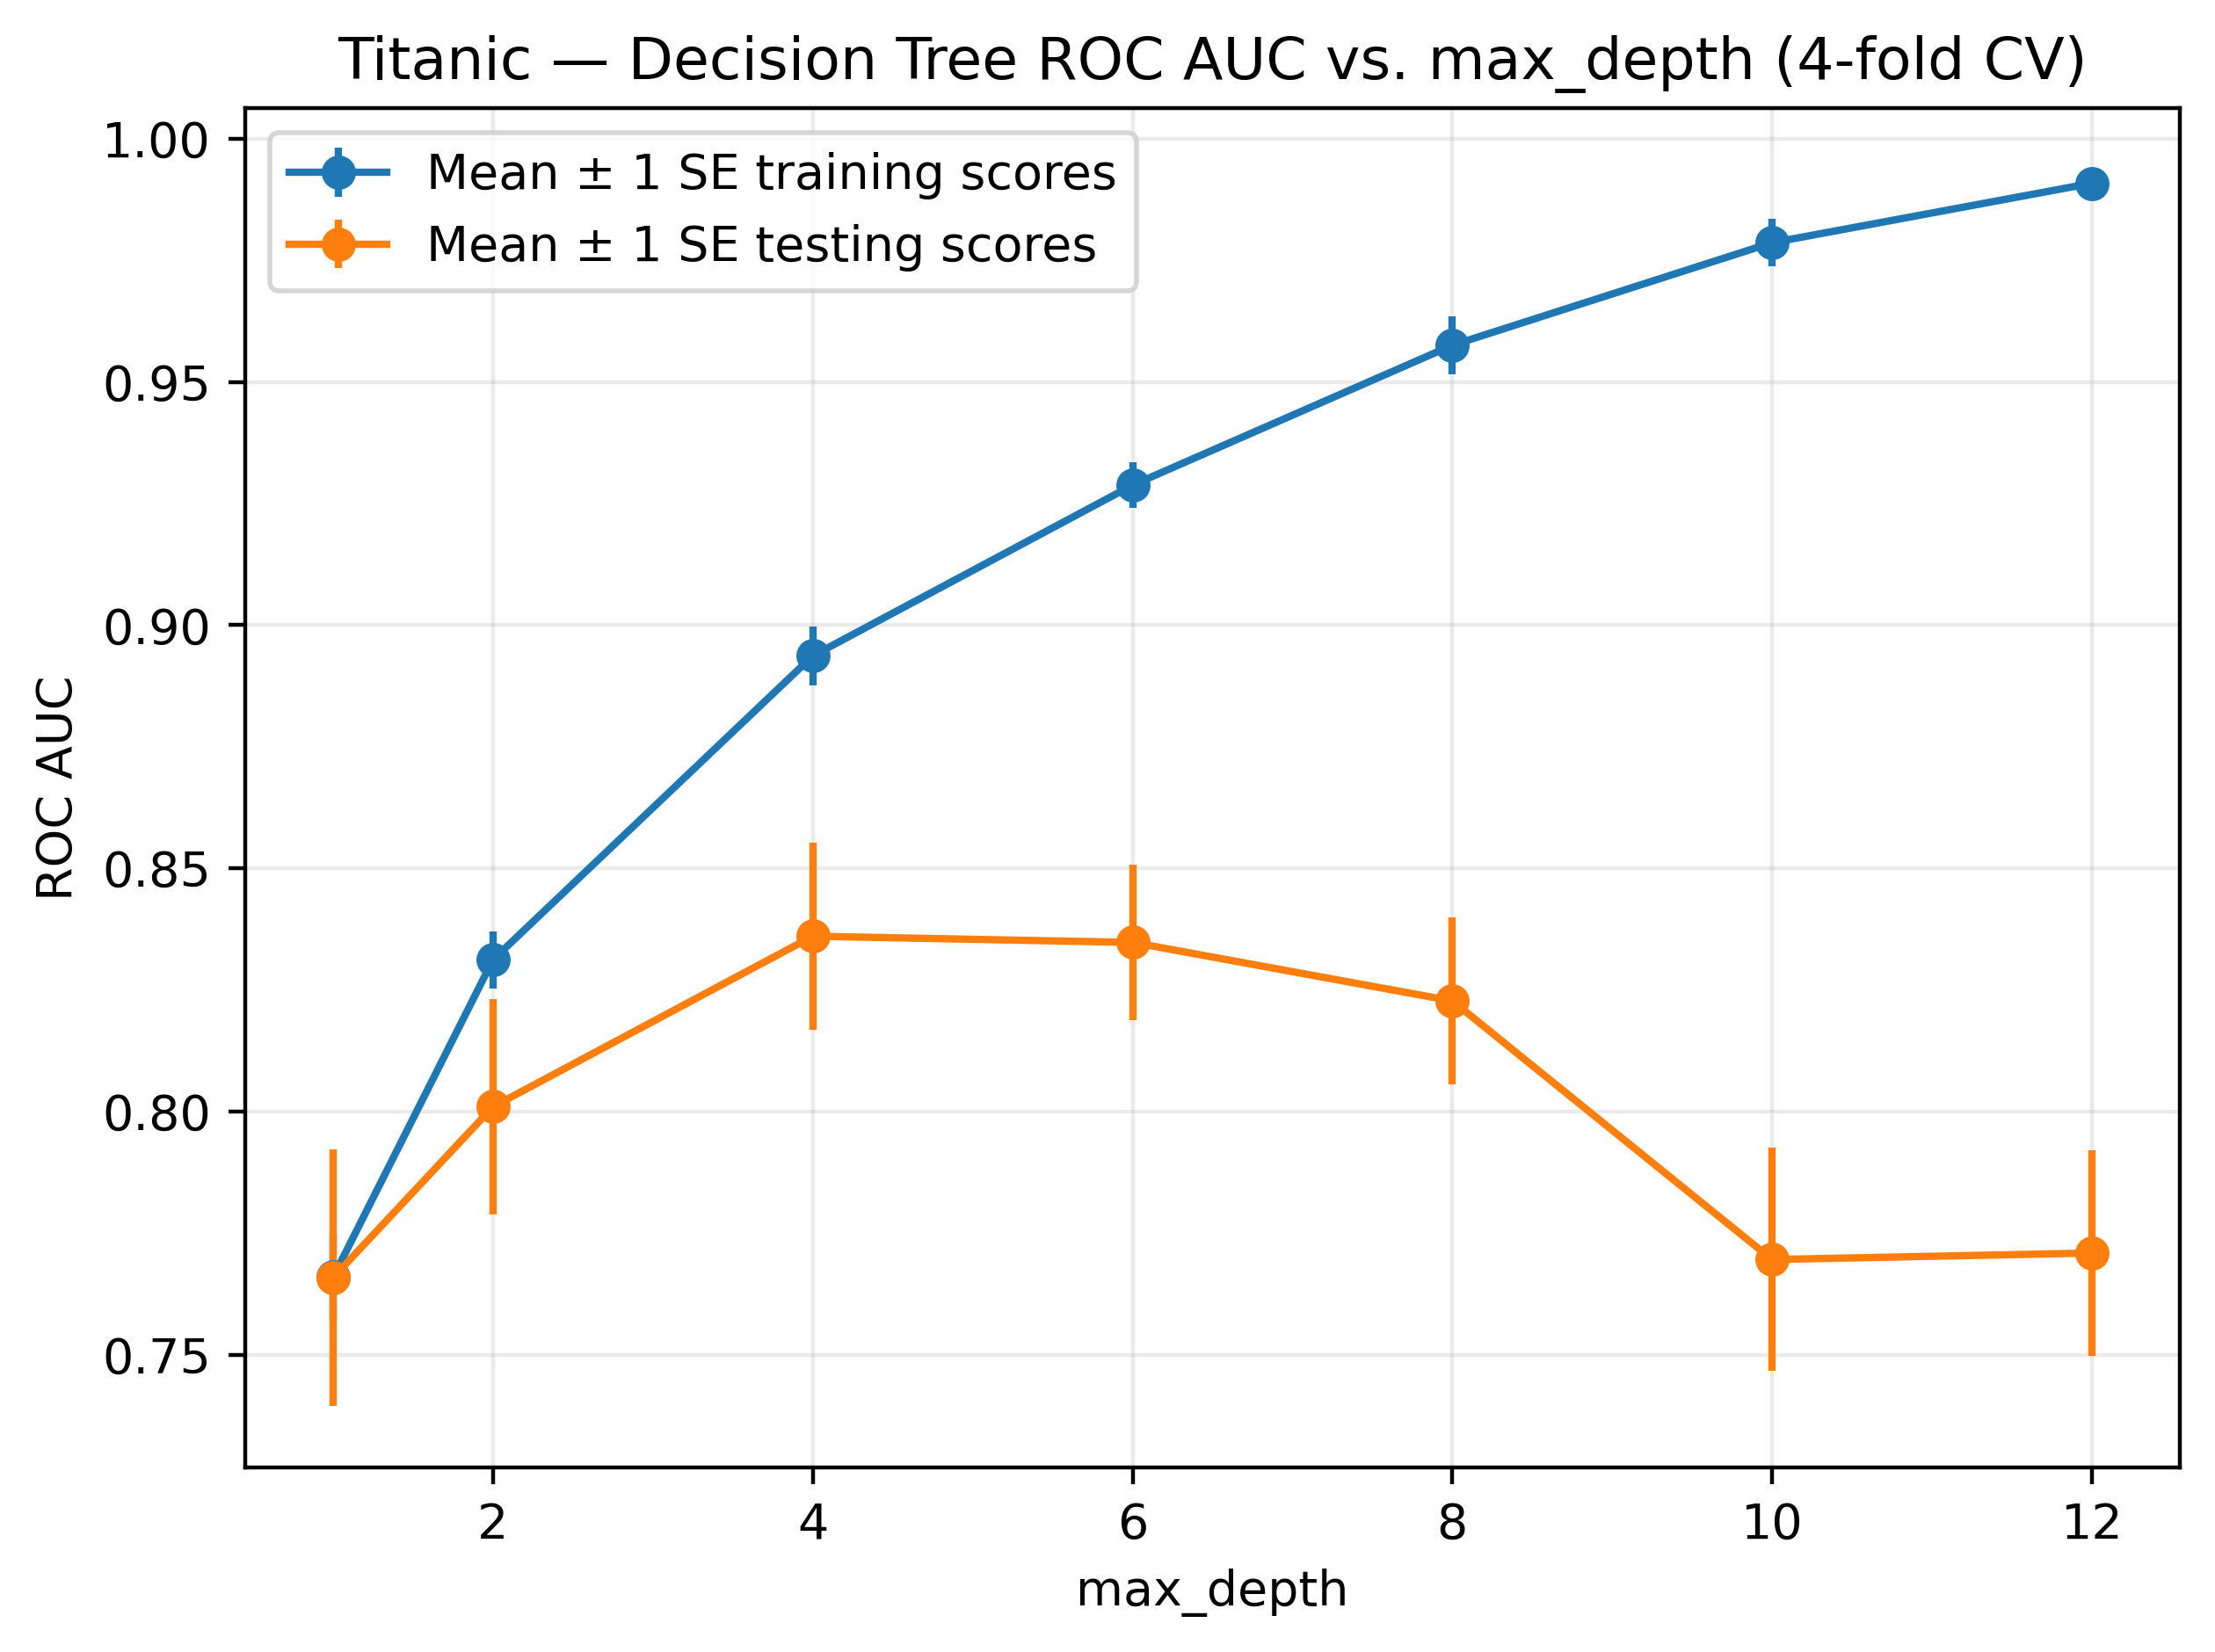

Biểu đồ đã lưu: titanic_dt_gridsearch_roc_auc.png
Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best params (RF, Titanic): {'n_estimators': 70}
Best CV ROC AUC (RF, Titanic): 0.8551845052213873


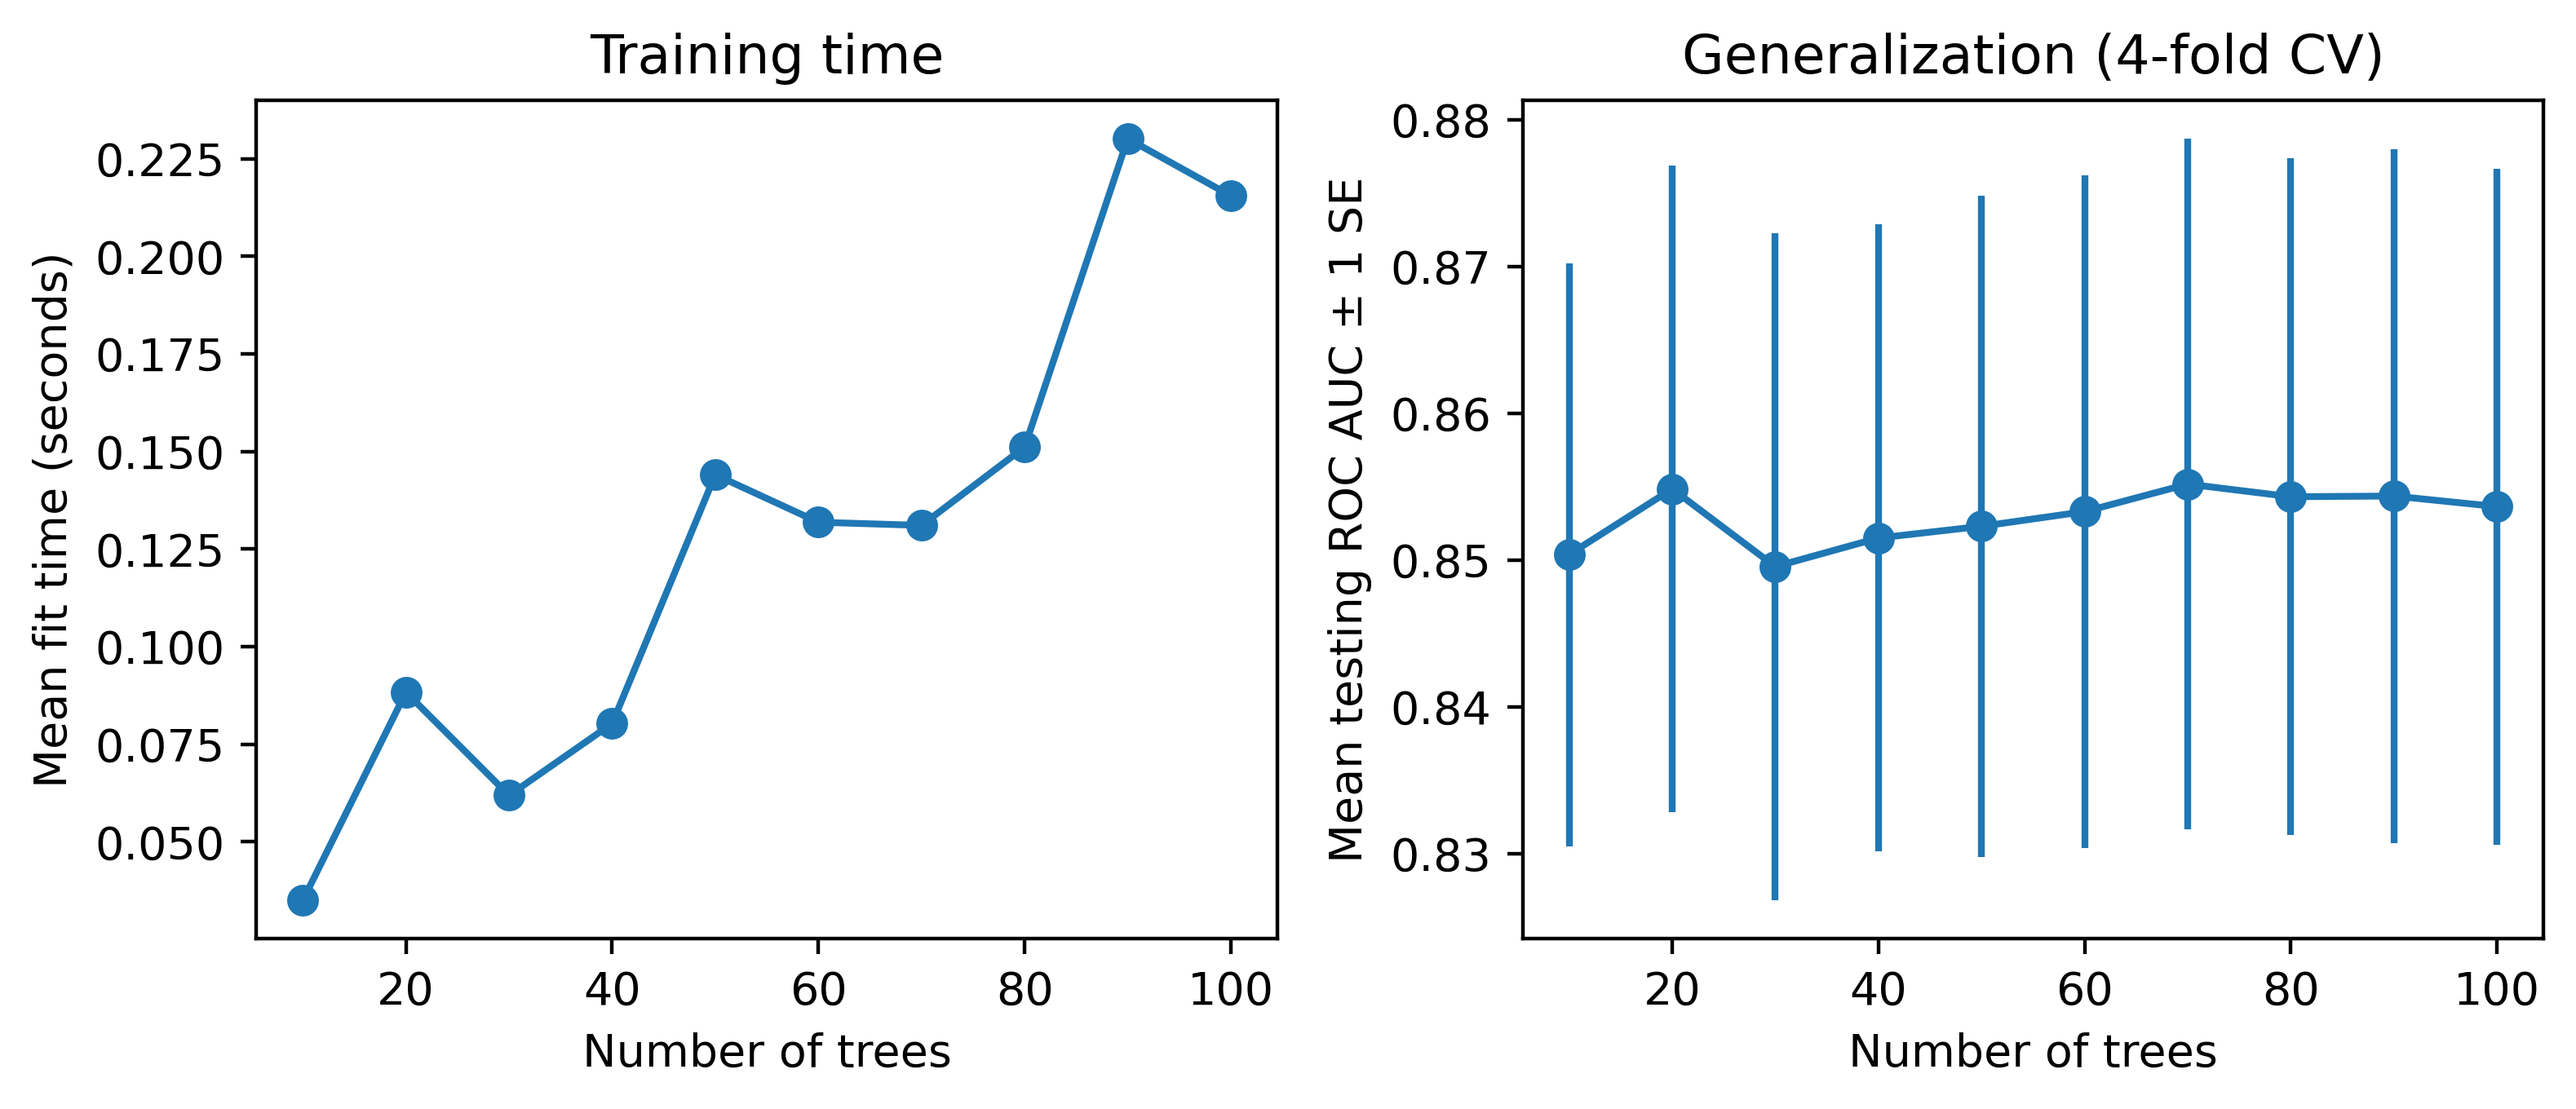

Đã lưu biểu đồ: titanic_rf_gridsearch_plots.png
Test ROC AUC (RF best, Titanic): 0.8448616600790514

Classification report (RF best, Titanic):
               precision    recall  f1-score   support

           0       0.79      0.93      0.85       110
           1       0.84      0.61      0.71        69

    accuracy                           0.80       179
   macro avg       0.82      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



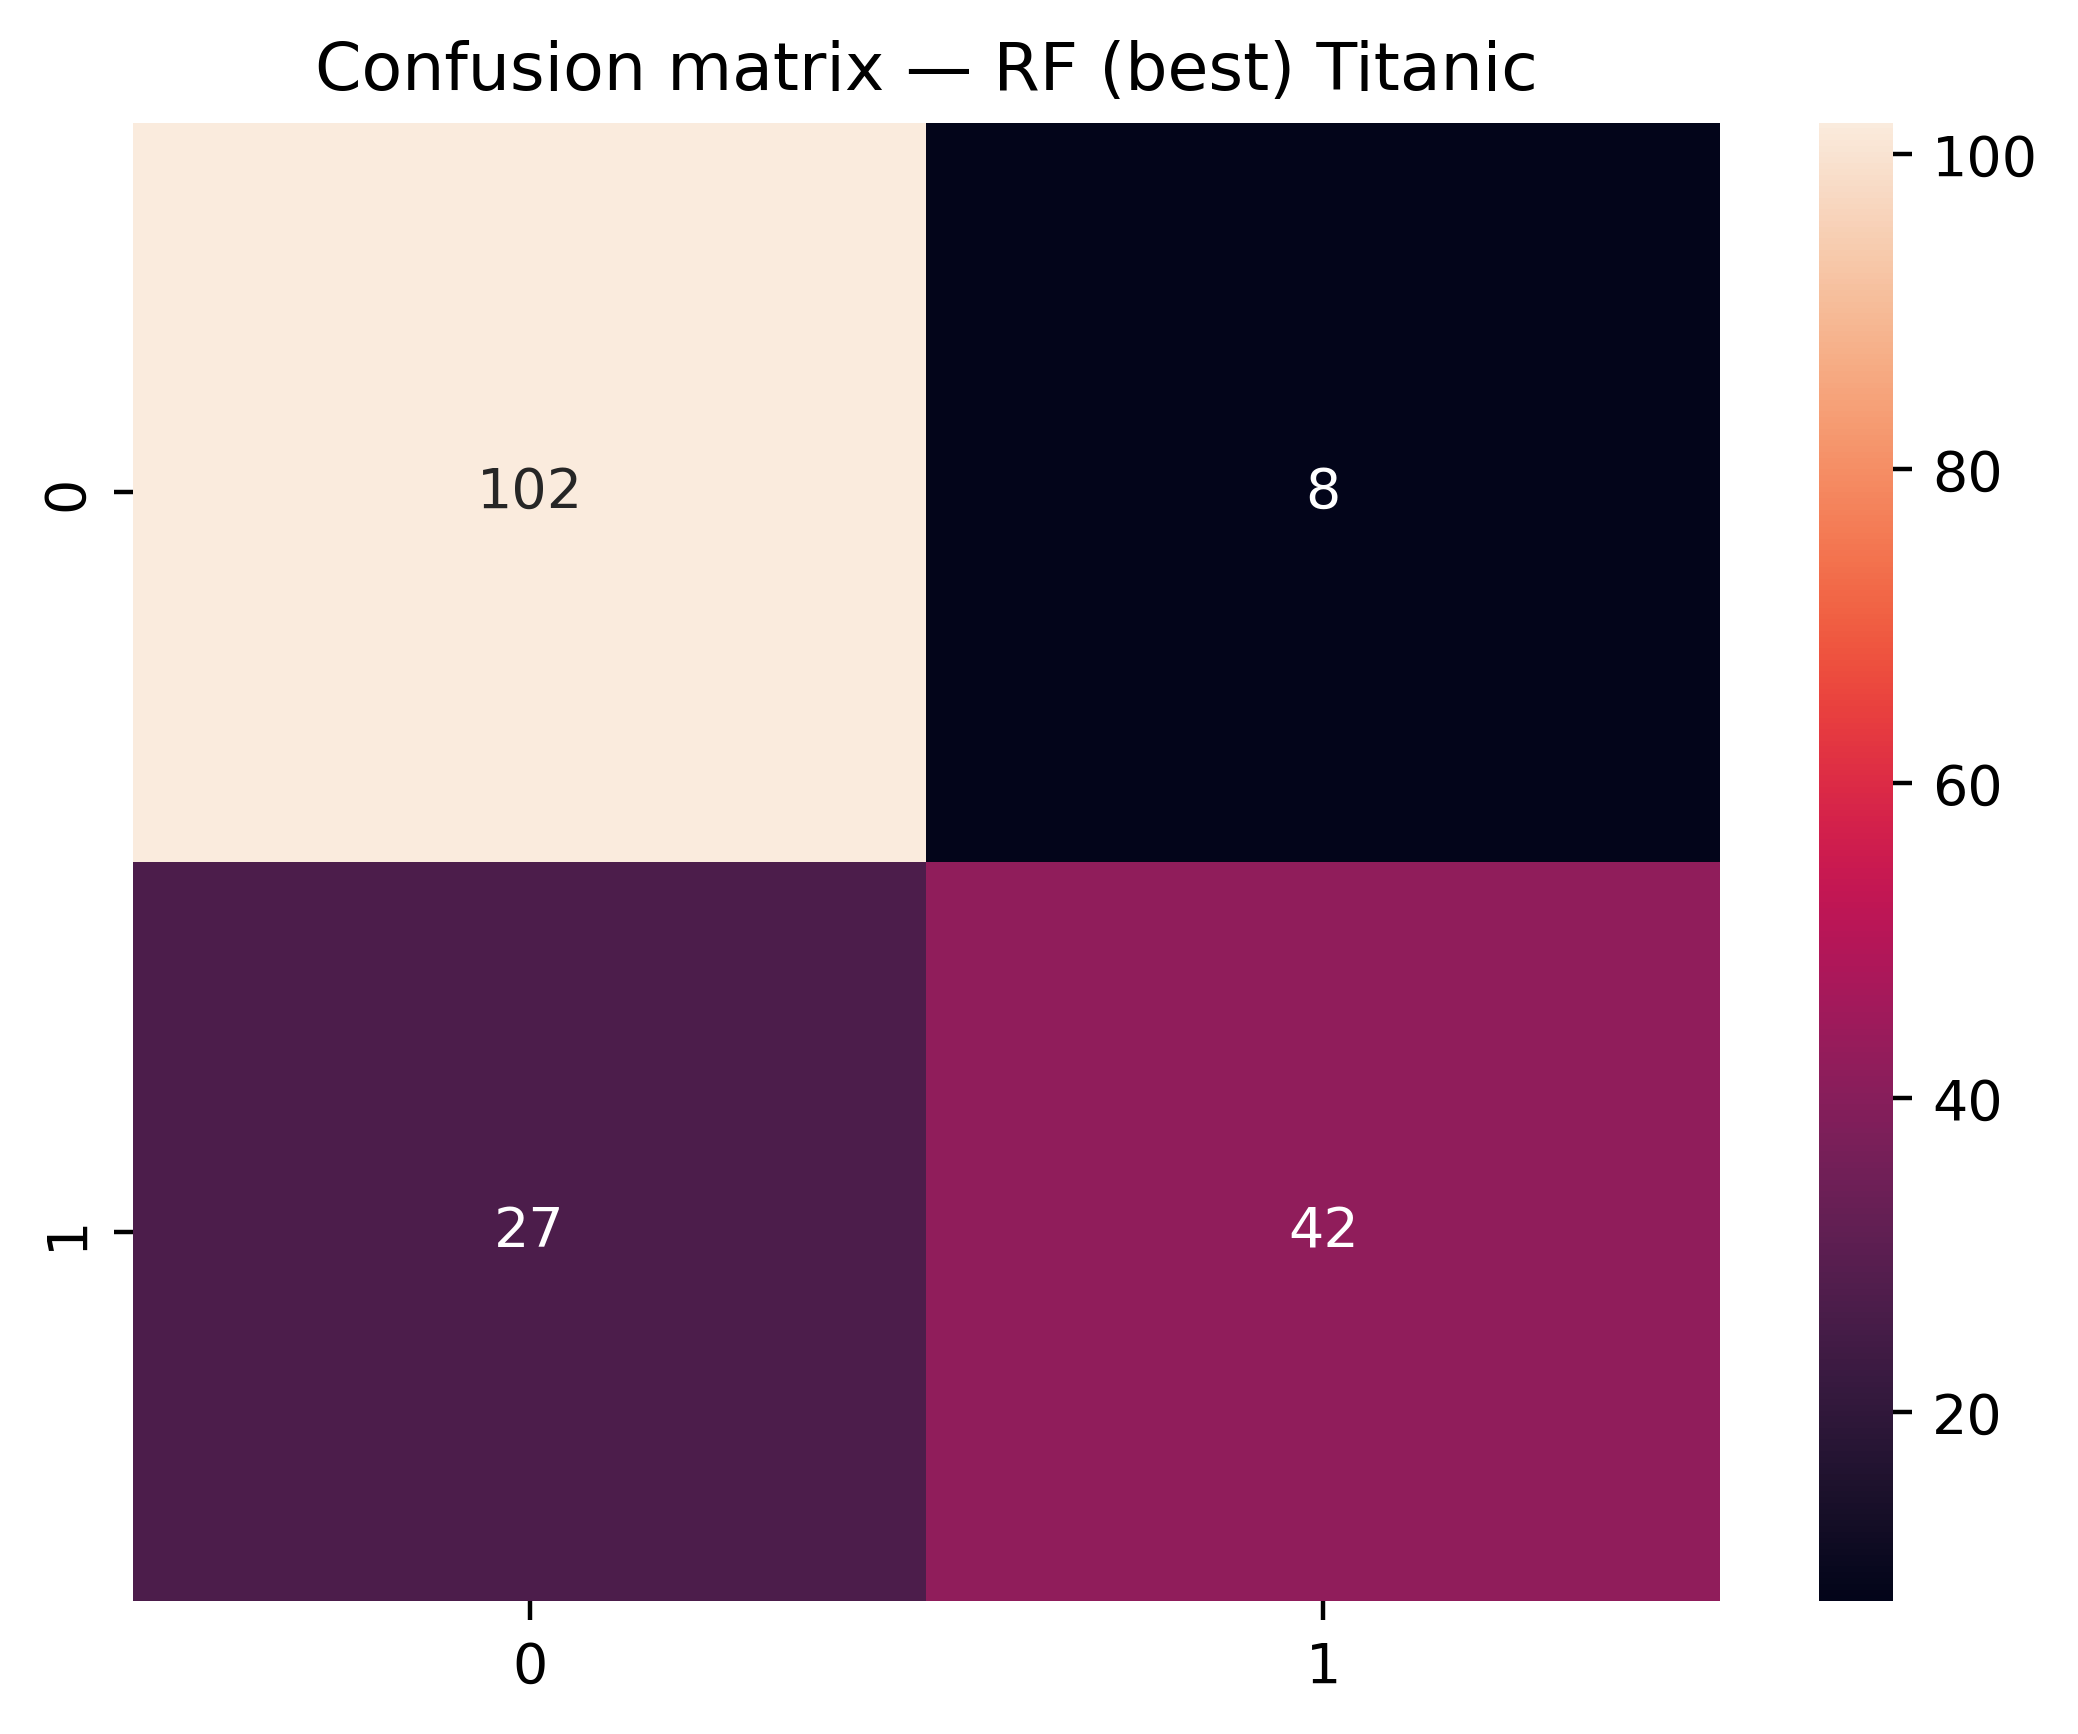

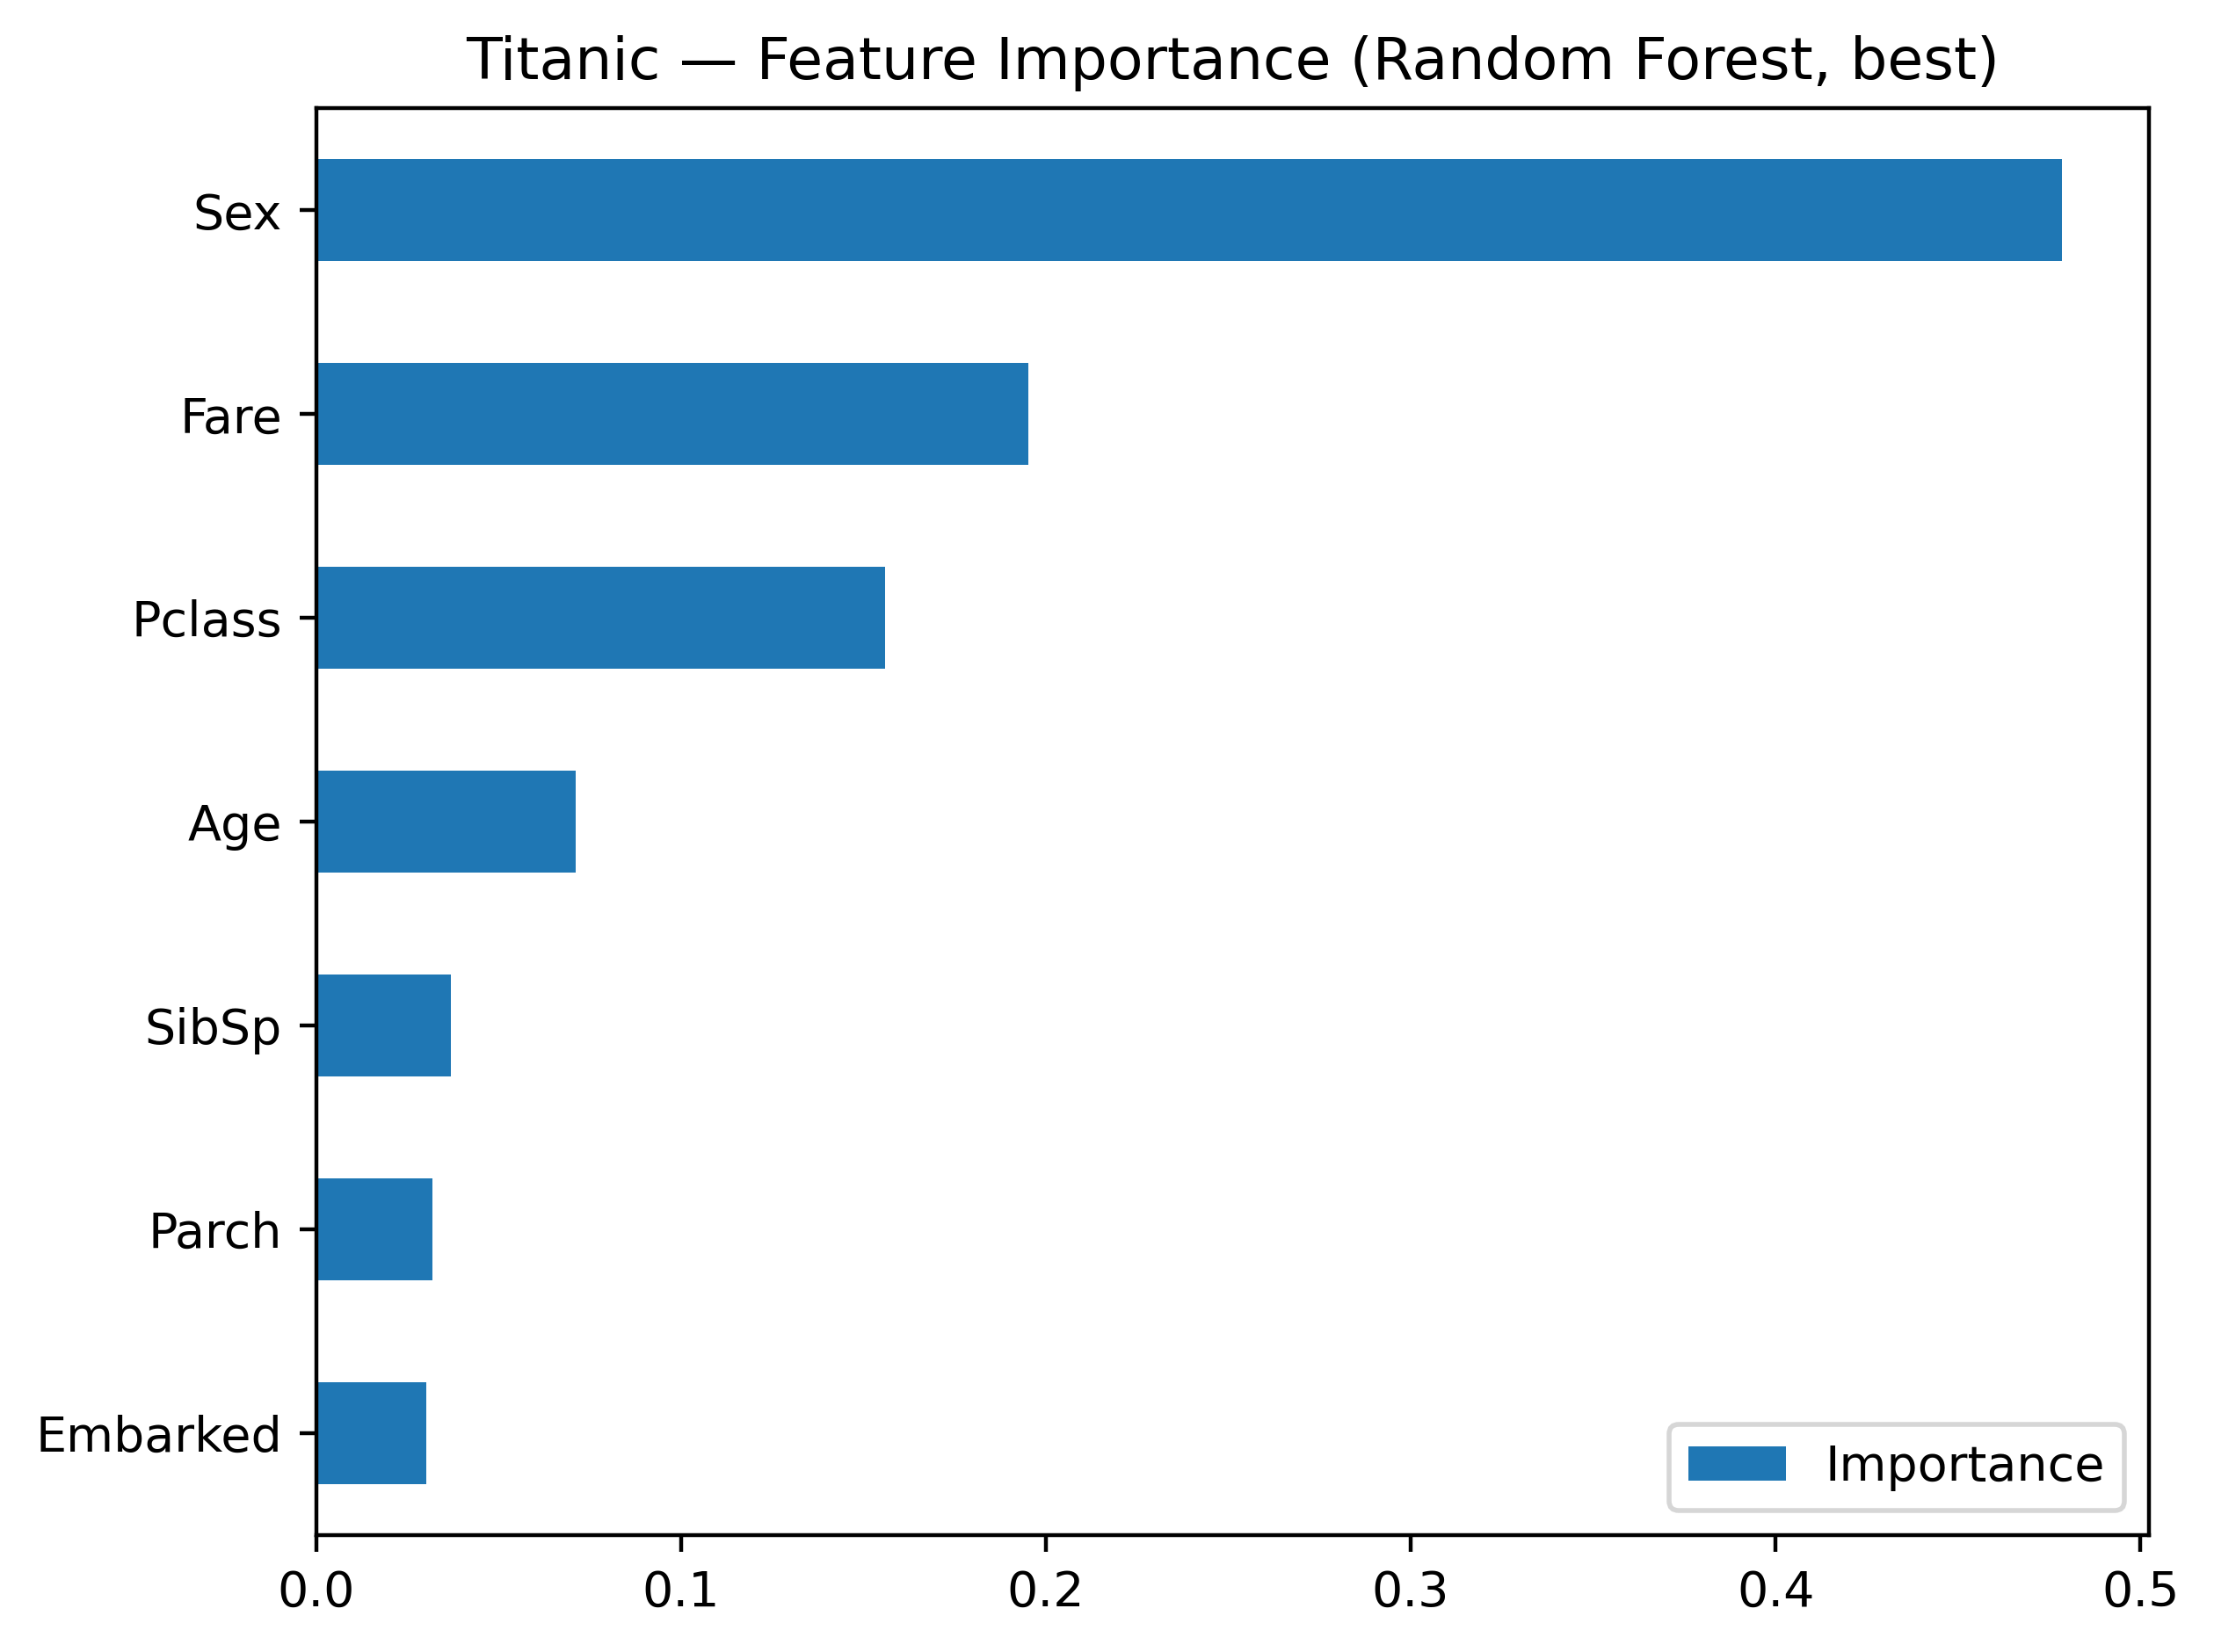

Đã lưu biểu đồ: titanic_rf_feature_importance.png


In [ ]:

# Biểu đồ ROC AUC theo max_depth 
cv_results_df_ti = pd.DataFrame(cv_ti.cv_results_)
try:
    x_depth_ti = cv_results_df_ti['param_max_depth'].astype(int)
except Exception:
    x_depth_ti = cv_results_df_ti['param_max_depth']

ax = plt.axes()
ax.errorbar(
    x_depth_ti,
    cv_results_df_ti['mean_train_score'],
    yerr=cv_results_df_ti['std_train_score']/np.sqrt(4),
    label='Mean ± 1 SE training scores',
    marker='o'
)
ax.errorbar(
    x_depth_ti,
    cv_results_df_ti['mean_test_score'],
    yerr=cv_results_df_ti['std_test_score']/np.sqrt(4),
    label='Mean ± 1 SE testing scores',
    marker='o'
)
ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.title('Titanic — Decision Tree ROC AUC vs. max_depth (4-fold CV)')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("titanic_dt_gridsearch_roc_auc.png", dpi=300)
plt.show()
print("Biểu đồ đã lưu: titanic_dt_gridsearch_roc_auc.png")

# --- 5) Random Forest + GridSearch số cây (10→100) ---
rf_ti = RandomForestClassifier(
    n_estimators=10, criterion='gini', max_depth=3,
    min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
    max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0,
    bootstrap=True, oob_score=False, n_jobs=None,
    random_state=4, verbose=0, warm_start=False, class_weight=None
)
rf_params_ex_ti = {'n_estimators': list(range(10, 110, 10))}
cv_rf_ex_ti = GridSearchCV(
    rf_ti, param_grid=rf_params_ex_ti,
    scoring='roc_auc', n_jobs=None,
    refit=True, cv=4, verbose=1,
    error_score=np.nan, return_train_score=True
)
cv_rf_ex_ti.fit(X_train, y_train)
print("Best params (RF, Titanic):", cv_rf_ex_ti.best_params_)
print("Best CV ROC AUC (RF, Titanic):", cv_rf_ex_ti.best_score_)

# Biểu đồ thời gian fit & ROC AUC theo số cây 
cv_rf_ex_results_df_ti = pd.DataFrame(cv_rf_ex_ti.cv_results_)
try:
    x_trees_ti = cv_rf_ex_results_df_ti['param_n_estimators'].astype(int)
except Exception:
    x_trees_ti = cv_rf_ex_results_df_ti['param_n_estimators']

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 3.5))
axs[0].plot(x_trees_ti, cv_rf_ex_results_df_ti['mean_fit_time'], '-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[0].set_title('Training time')

axs[1].errorbar(
    x_trees_ti,
    cv_rf_ex_results_df_ti['mean_test_score'],
    yerr=cv_rf_ex_results_df_ti['std_test_score'] / np.sqrt(4),
    fmt='-o'
)
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC ± 1 SE')
axs[1].set_title('Generalization (4-fold CV)')

plt.tight_layout()
plt.savefig("titanic_rf_gridsearch_plots.png", dpi=300)
plt.show()
print("Đã lưu biểu đồ: titanic_rf_gridsearch_plots.png")

# Đánh giá mô hình RF tốt nhất trên test
best_rf_ti = cv_rf_ex_ti.best_estimator_
y_proba_rf_ti = best_rf_ti.predict_proba(X_test)[:, 1]
y_pred_rf_ti  = best_rf_ti.predict(X_test)
print("Test ROC AUC (RF best, Titanic):", roc_auc_score(y_test, y_proba_rf_ti))
print("\nClassification report (RF best, Titanic):\n", classification_report(y_test, y_pred_rf_ti))
sns.heatmap(confusion_matrix(y_test, y_pred_rf_ti), annot=True, fmt='d')
plt.title("Confusion matrix — RF (best) Titanic")
plt.show()

# --- 6) Tham số tối ưu & Feature importance 
cv_rf_ex_ti.best_params_  # ví dụ {'n_estimators': 50}

feat_imp_df_ti = pd.DataFrame({
    'Importance': cv_rf_ex_ti.best_estimator_.feature_importances_
}, index=features_response_ti[:-1])

feat_imp_df_ti.sort_values('Importance', ascending=True).plot.barh()
plt.title("Titanic — Feature Importance (Random Forest, best)")
plt.tight_layout()
plt.savefig("titanic_rf_feature_importance.png", dpi=300)
plt.show()
print("Đã lưu biểu đồ: titanic_rf_feature_importance.png")


## 2.1.4. Bài tập thực hành 2 Xây dựng cây quyết định và rừng cây trên dữ liệu bệnh tiểu đường. 


In [39]:
# ⏬ Download dataset (uciml/pima-indians-diabetes-database)
DATASET_DB = "uciml/pima-indians-diabetes-database"
DATA_DIR_DB = Path("data_diabetes")
TARGET_FILE_DB = Path("data_diabetes.csv")

if not TARGET_FILE_DB.exists():
    DATA_DIR_DB.mkdir(parents=True, exist_ok=True)
    api.dataset_download_files(DATASET_DB, path=str(DATA_DIR_DB), unzip=True)
    src_csv = DATA_DIR_DB / "diabetes.csv"
    assert src_csv.exists(), "Không thấy diabetes.csv sau khi unzip."
    shutil.copy2(src_csv, TARGET_FILE_DB)
    print(f"✅ Đã tạo {TARGET_FILE_DB.name}")
else:
    print("✅ Đã có data_diabetes.csv — bỏ qua tải.")


Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database
✅ Đã tạo data_diabetes.csv


In [40]:
# ⏬ Load & features/response
df_db = pd.read_csv("data_diabetes.csv")

# Giữ phong cách features_response như bài trước
# (đưa Outcome làm cột cuối để tái dùng split)
cols = df_db.columns.tolist()
cols = [c for c in cols if c != "Outcome"] + ["Outcome"]
features_response_db = cols

# (Tùy chọn) Điền thiếu nếu có
for c in ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]:
    if c in df_db.columns:
        # Một số bản ghi 0 có thể xem như thiếu; để đơn giản giữ nguyên theo đề
        pass

df_db[features_response_db].head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    df_db[features_response_db[:-1]].values,
    df_db["Outcome"].values,
    test_size=0.2,
    random_state=24,
    stratify=df_db["Outcome"].values
)
X_train.shape, X_test.shape


((614, 8), (154, 8))

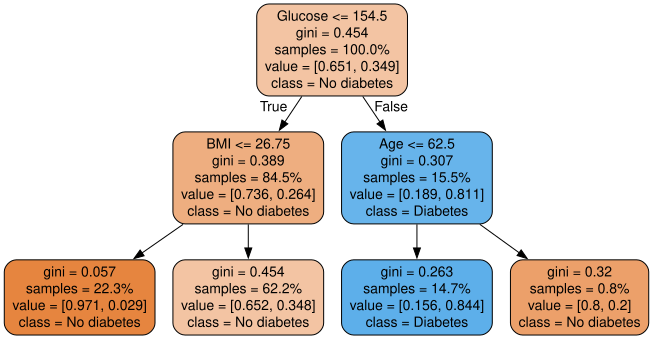

In [ ]:
dt_db = tree.DecisionTreeClassifier(max_depth=2, random_state=24)
dt_db.fit(X_train, y_train)

dot_data_db = tree.export_graphviz(
    dt_db,
    out_file=None,
    filled=True,
    rounded=True,
    feature_names=features_response_db[:-1],
    proportion=True,
    class_names=['No diabetes','Diabetes']
)
graph_db = graphviz.Source(dot_data_db)
graph_db  # hiển thị



Fitting 4 folds for each of 7 candidates, totalling 28 fits


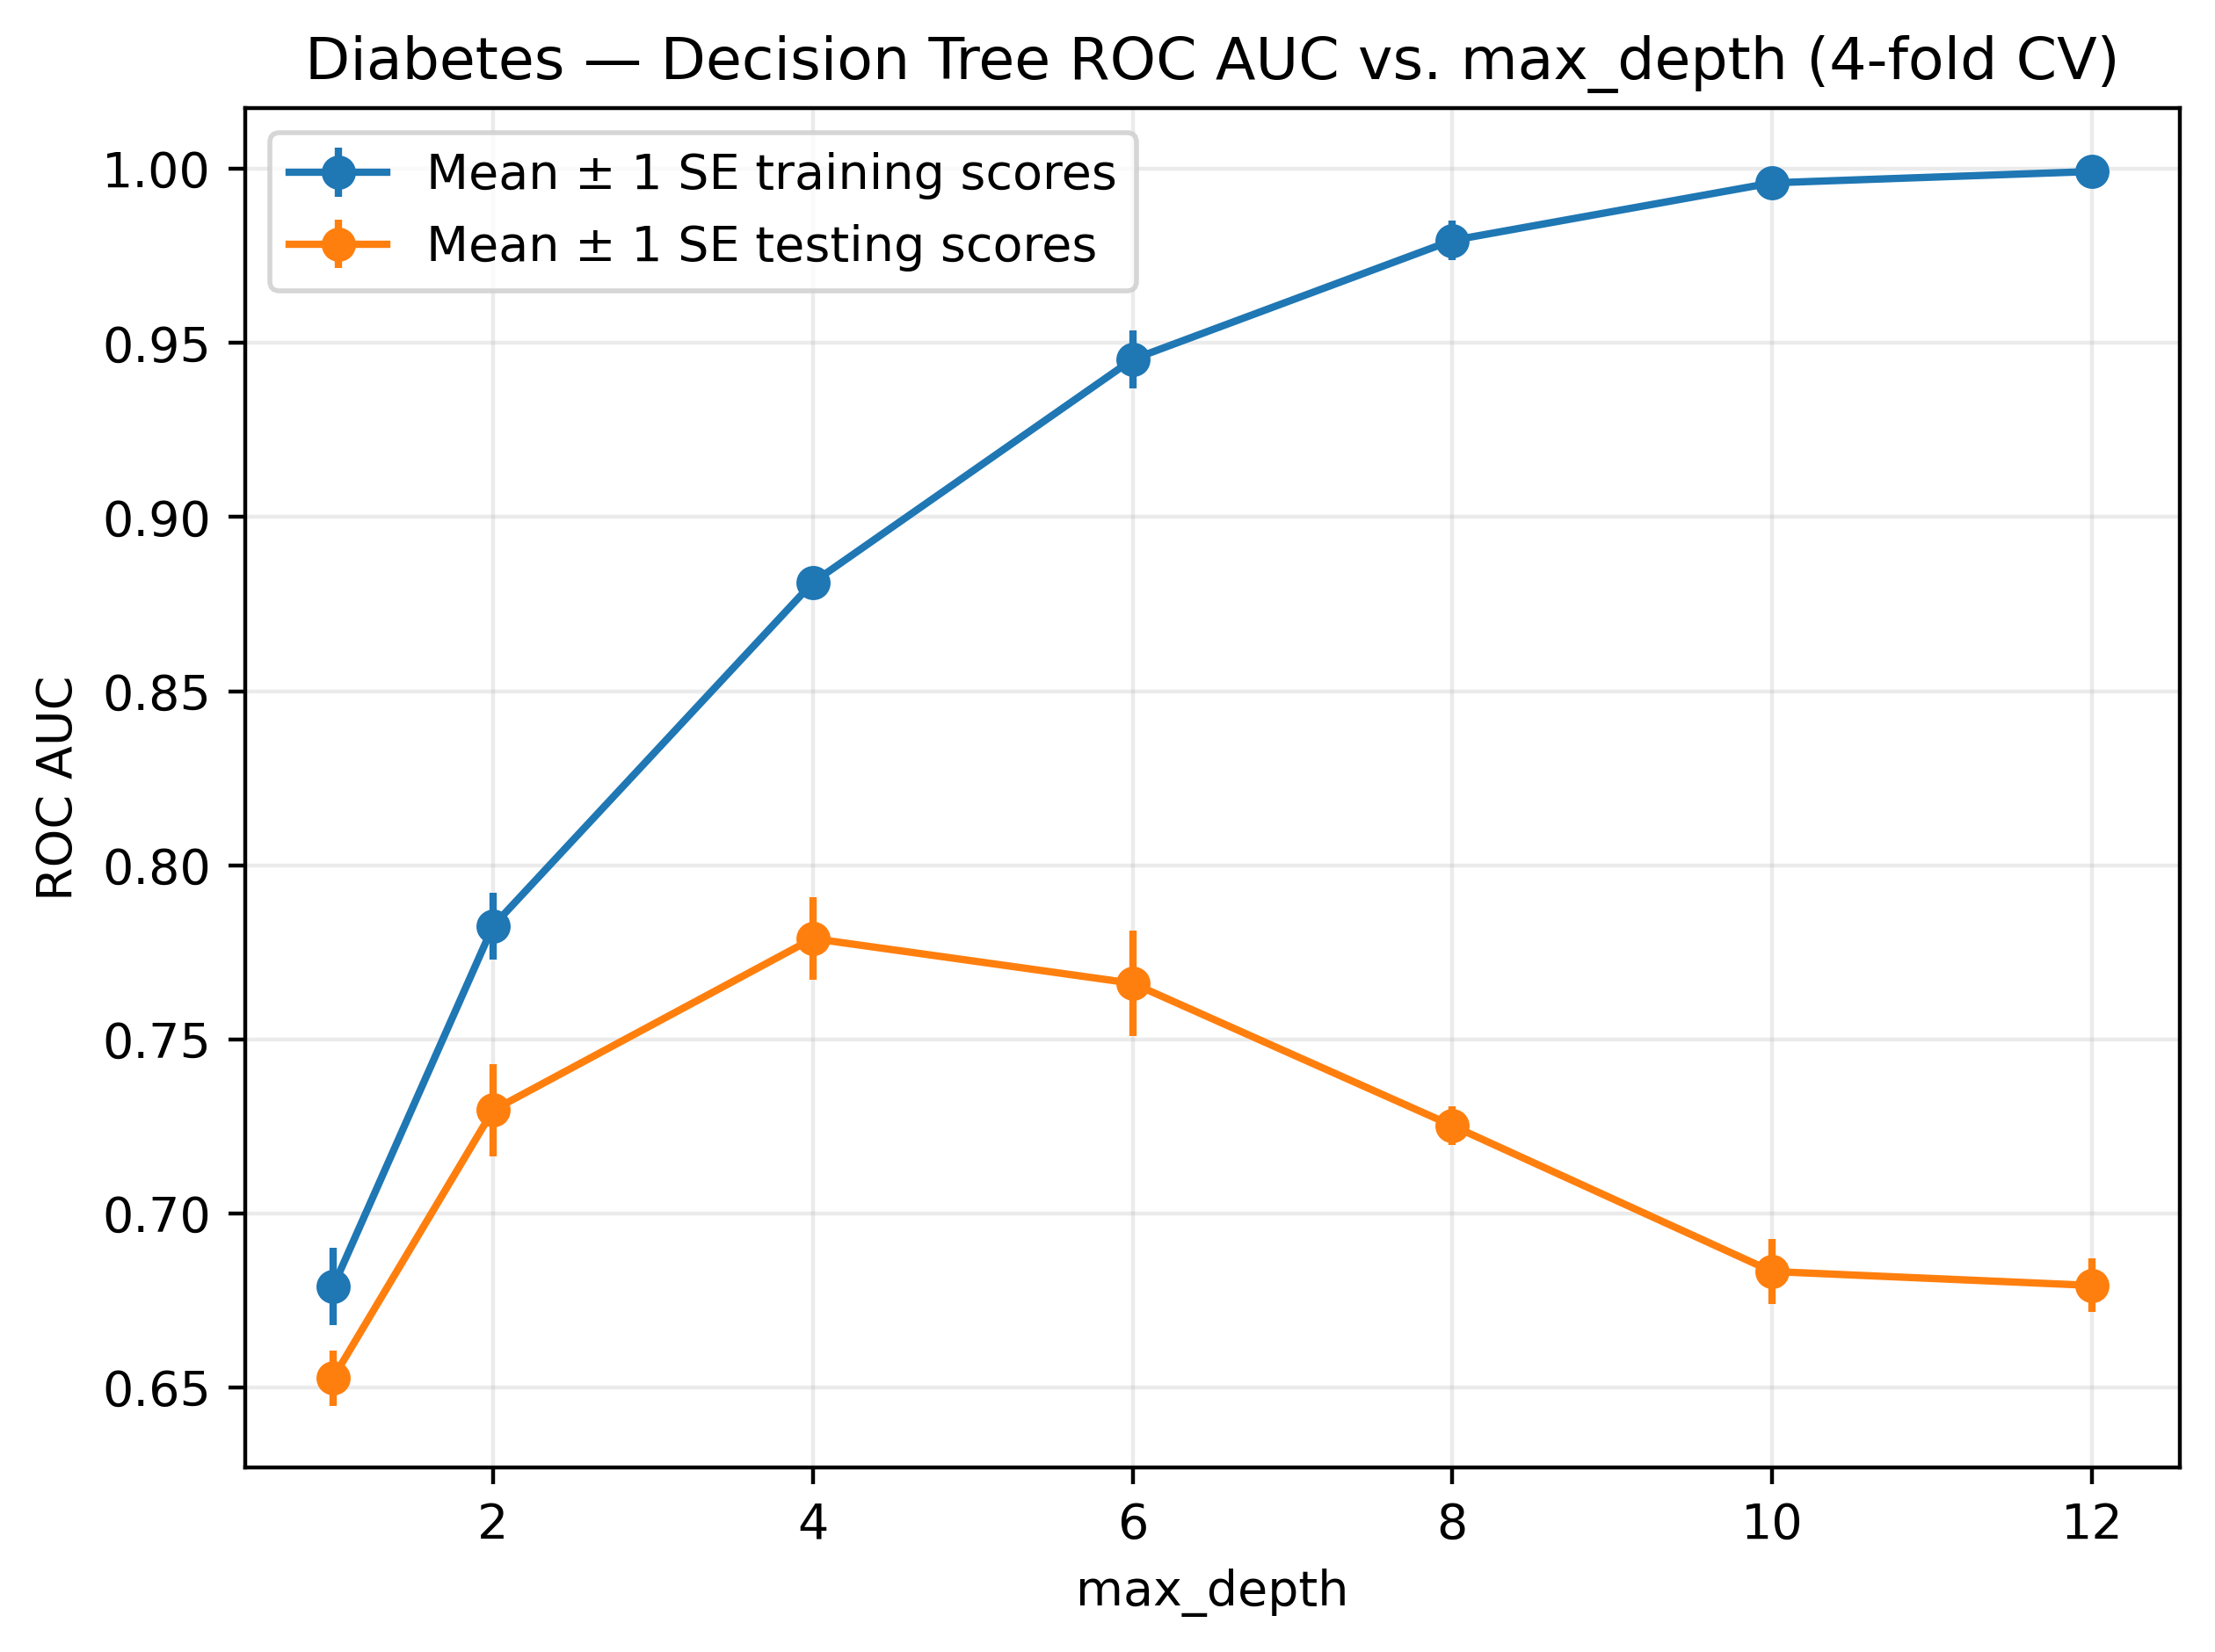

In [43]:
params_db = {'max_depth':[1,2,4,6,8,10,12]}
cv_db = GridSearchCV(
    tree.DecisionTreeClassifier(random_state=24),
    param_grid=params_db,
    scoring='roc_auc',
    n_jobs=None,
    refit=True,
    cv=4,
    verbose=1,
    error_score=np.nan,
    return_train_score=True
)
cv_db.fit(X_train, y_train)

cv_results_df_db = pd.DataFrame(cv_db.cv_results_)
try:
    x_depth_db = cv_results_df_db['param_max_depth'].astype(int)
except Exception:
    x_depth_db = cv_results_df_db['param_max_depth']

ax = plt.axes()
ax.errorbar(
    x_depth_db,
    cv_results_df_db['mean_train_score'],
    yerr=cv_results_df_db['std_train_score']/np.sqrt(4),
    label='Mean ± 1 SE training scores',
    marker='o'
)
ax.errorbar(
    x_depth_db,
    cv_results_df_db['mean_test_score'],
    yerr=cv_results_df_db['std_test_score']/np.sqrt(4),
    label='Mean ± 1 SE testing scores',
    marker='o'
)
ax.legend()
plt.xlabel('max_depth')
plt.ylabel('ROC AUC')
plt.title('Diabetes — Decision Tree ROC AUC vs. max_depth (4-fold CV)')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("diabetes_dt_gridsearch_roc_auc.png", dpi=300)
plt.show()

best_dt_db = cv_db.best_estimator_


Fitting 4 folds for each of 10 candidates, totalling 40 fits
Best params (RF, Diabetes): {'n_estimators': 30}
Best CV ROC AUC (RF, Diabetes): 0.8353611984626136


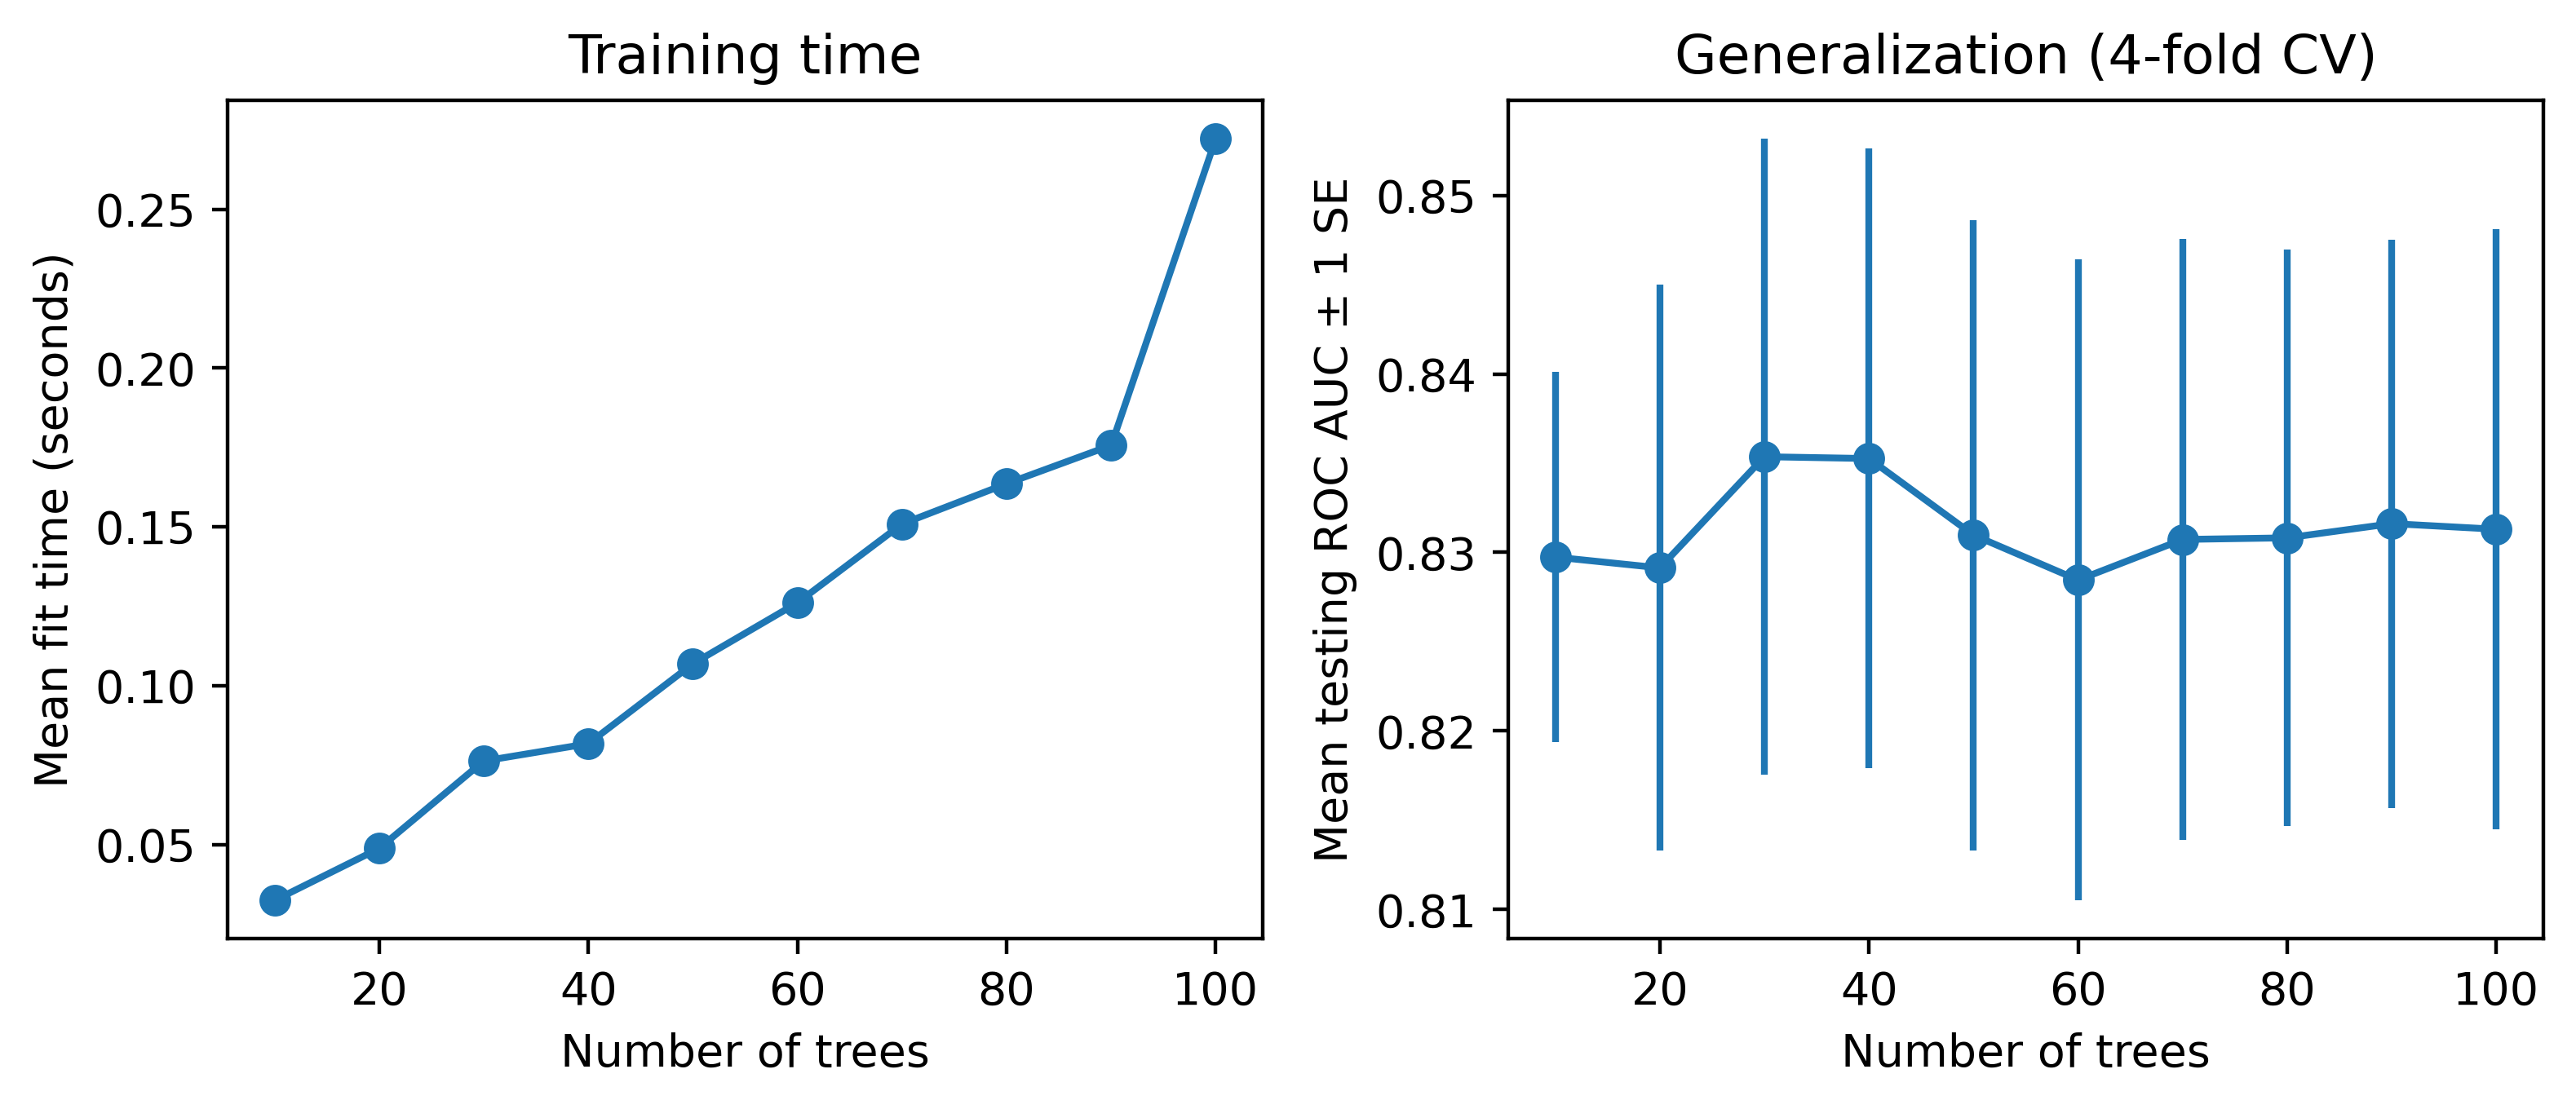

In [44]:
rf_db = RandomForestClassifier(
    n_estimators=10, criterion='gini', max_depth=3,
    min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
    max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0,
    bootstrap=True, oob_score=False, n_jobs=None,
    random_state=4, verbose=0, warm_start=False, class_weight=None
)

rf_params_ex_db = {'n_estimators': list(range(10,110,10))}
cv_rf_ex_db = GridSearchCV(
    rf_db, param_grid=rf_params_ex_db,
    scoring='roc_auc', n_jobs=None,
    refit=True, cv=4, verbose=1,
    error_score=np.nan, return_train_score=True
)
cv_rf_ex_db.fit(X_train, y_train)

print("Best params (RF, Diabetes):", cv_rf_ex_db.best_params_)
print("Best CV ROC AUC (RF, Diabetes):", cv_rf_ex_db.best_score_)

cv_rf_ex_results_df_db = pd.DataFrame(cv_rf_ex_db.cv_results_)
try:
    x_trees_db = cv_rf_ex_results_df_db['param_n_estimators'].astype(int)
except Exception:
    x_trees_db = cv_rf_ex_results_df_db['param_n_estimators']

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8, 3.5))
axs[0].plot(x_trees_db, cv_rf_ex_results_df_db['mean_fit_time'], '-o')
axs[0].set_xlabel('Number of trees')
axs[0].set_ylabel('Mean fit time (seconds)')
axs[0].set_title('Training time')

axs[1].errorbar(
    x_trees_db,
    cv_rf_ex_results_df_db['mean_test_score'],
    yerr=cv_rf_ex_results_df_db['std_test_score'] / np.sqrt(4),
    fmt='-o'
)
axs[1].set_xlabel('Number of trees')
axs[1].set_ylabel('Mean testing ROC AUC ± 1 SE')
axs[1].set_title('Generalization (4-fold CV)')

plt.tight_layout()
plt.savefig("diabetes_rf_gridsearch_plots.png", dpi=300)
plt.show()

best_rf_db = cv_rf_ex_db.best_estimator_


Test ROC AUC (RF best, Diabetes): 0.7999074074074073

Classification report (RF best, Diabetes):
               precision    recall  f1-score   support

           0       0.76      0.90      0.83       100
           1       0.72      0.48      0.58        54

    accuracy                           0.75       154
   macro avg       0.74      0.69      0.70       154
weighted avg       0.75      0.75      0.74       154



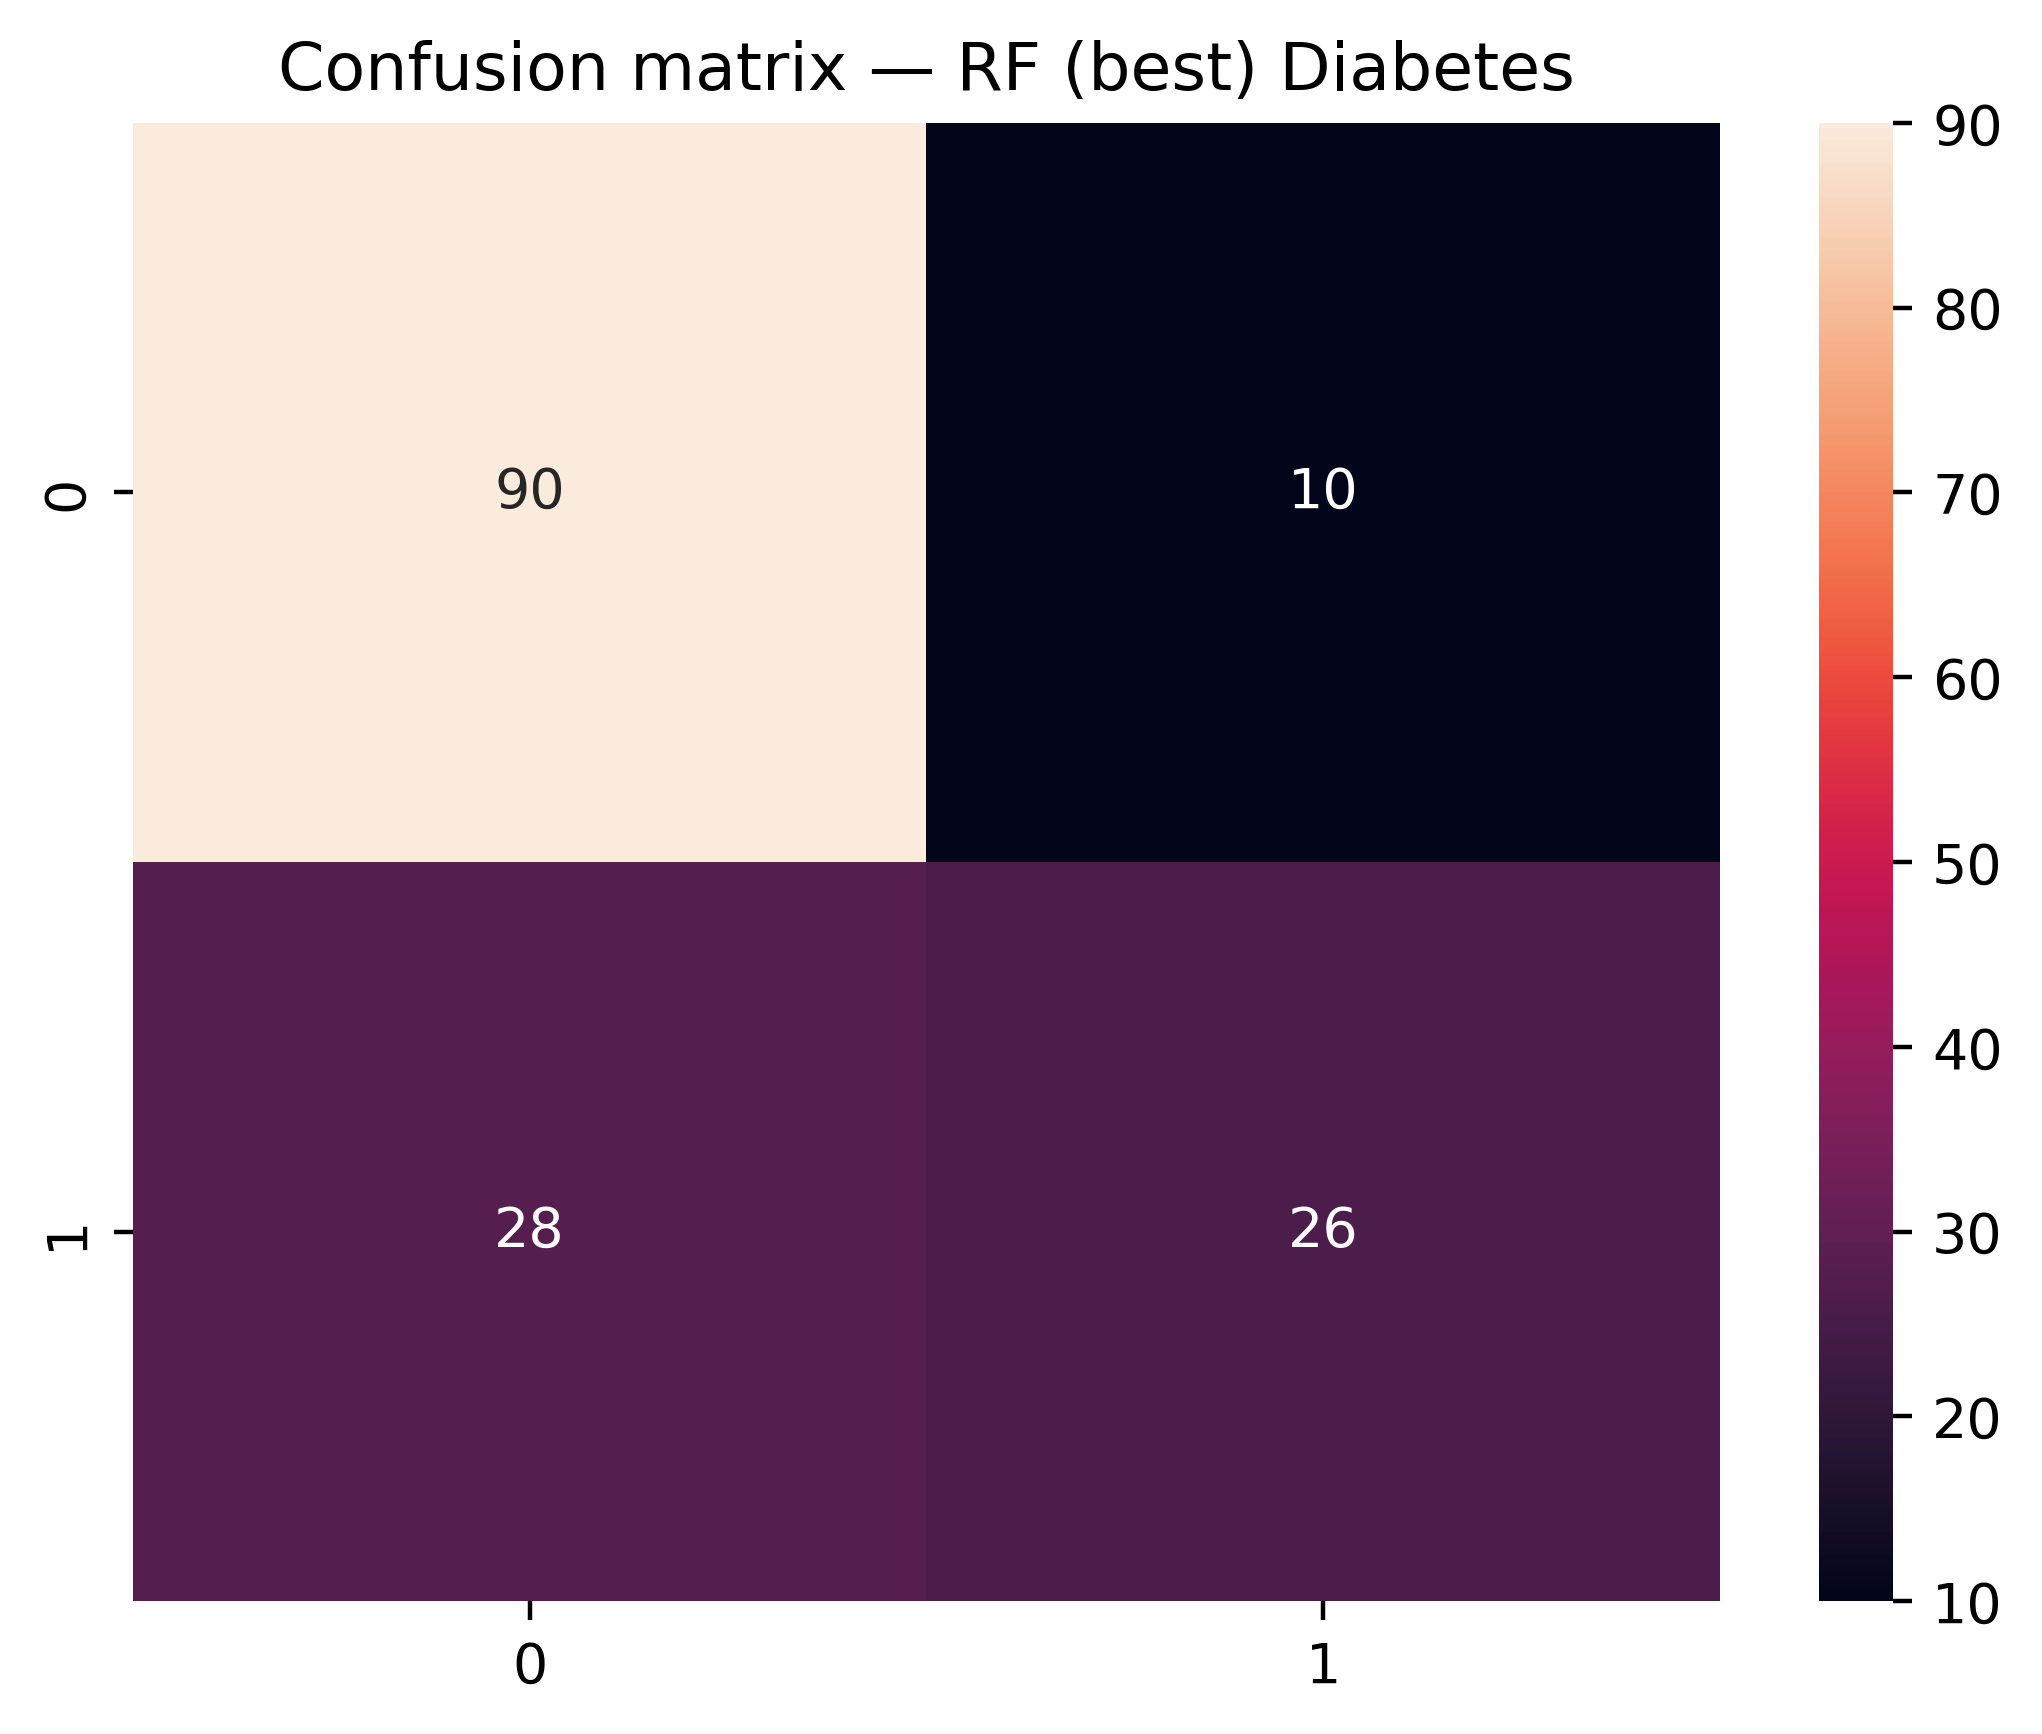

In [45]:
y_proba_rf_db = best_rf_db.predict_proba(X_test)[:, 1]
y_pred_rf_db  = best_rf_db.predict(X_test)

print("Test ROC AUC (RF best, Diabetes):", roc_auc_score(y_test, y_proba_rf_db))
print("\nClassification report (RF best, Diabetes):\n", classification_report(y_test, y_pred_rf_db))

sns.heatmap(confusion_matrix(y_test, y_pred_rf_db), annot=True, fmt='d')
plt.title("Confusion matrix — RF (best) Diabetes")
plt.show()


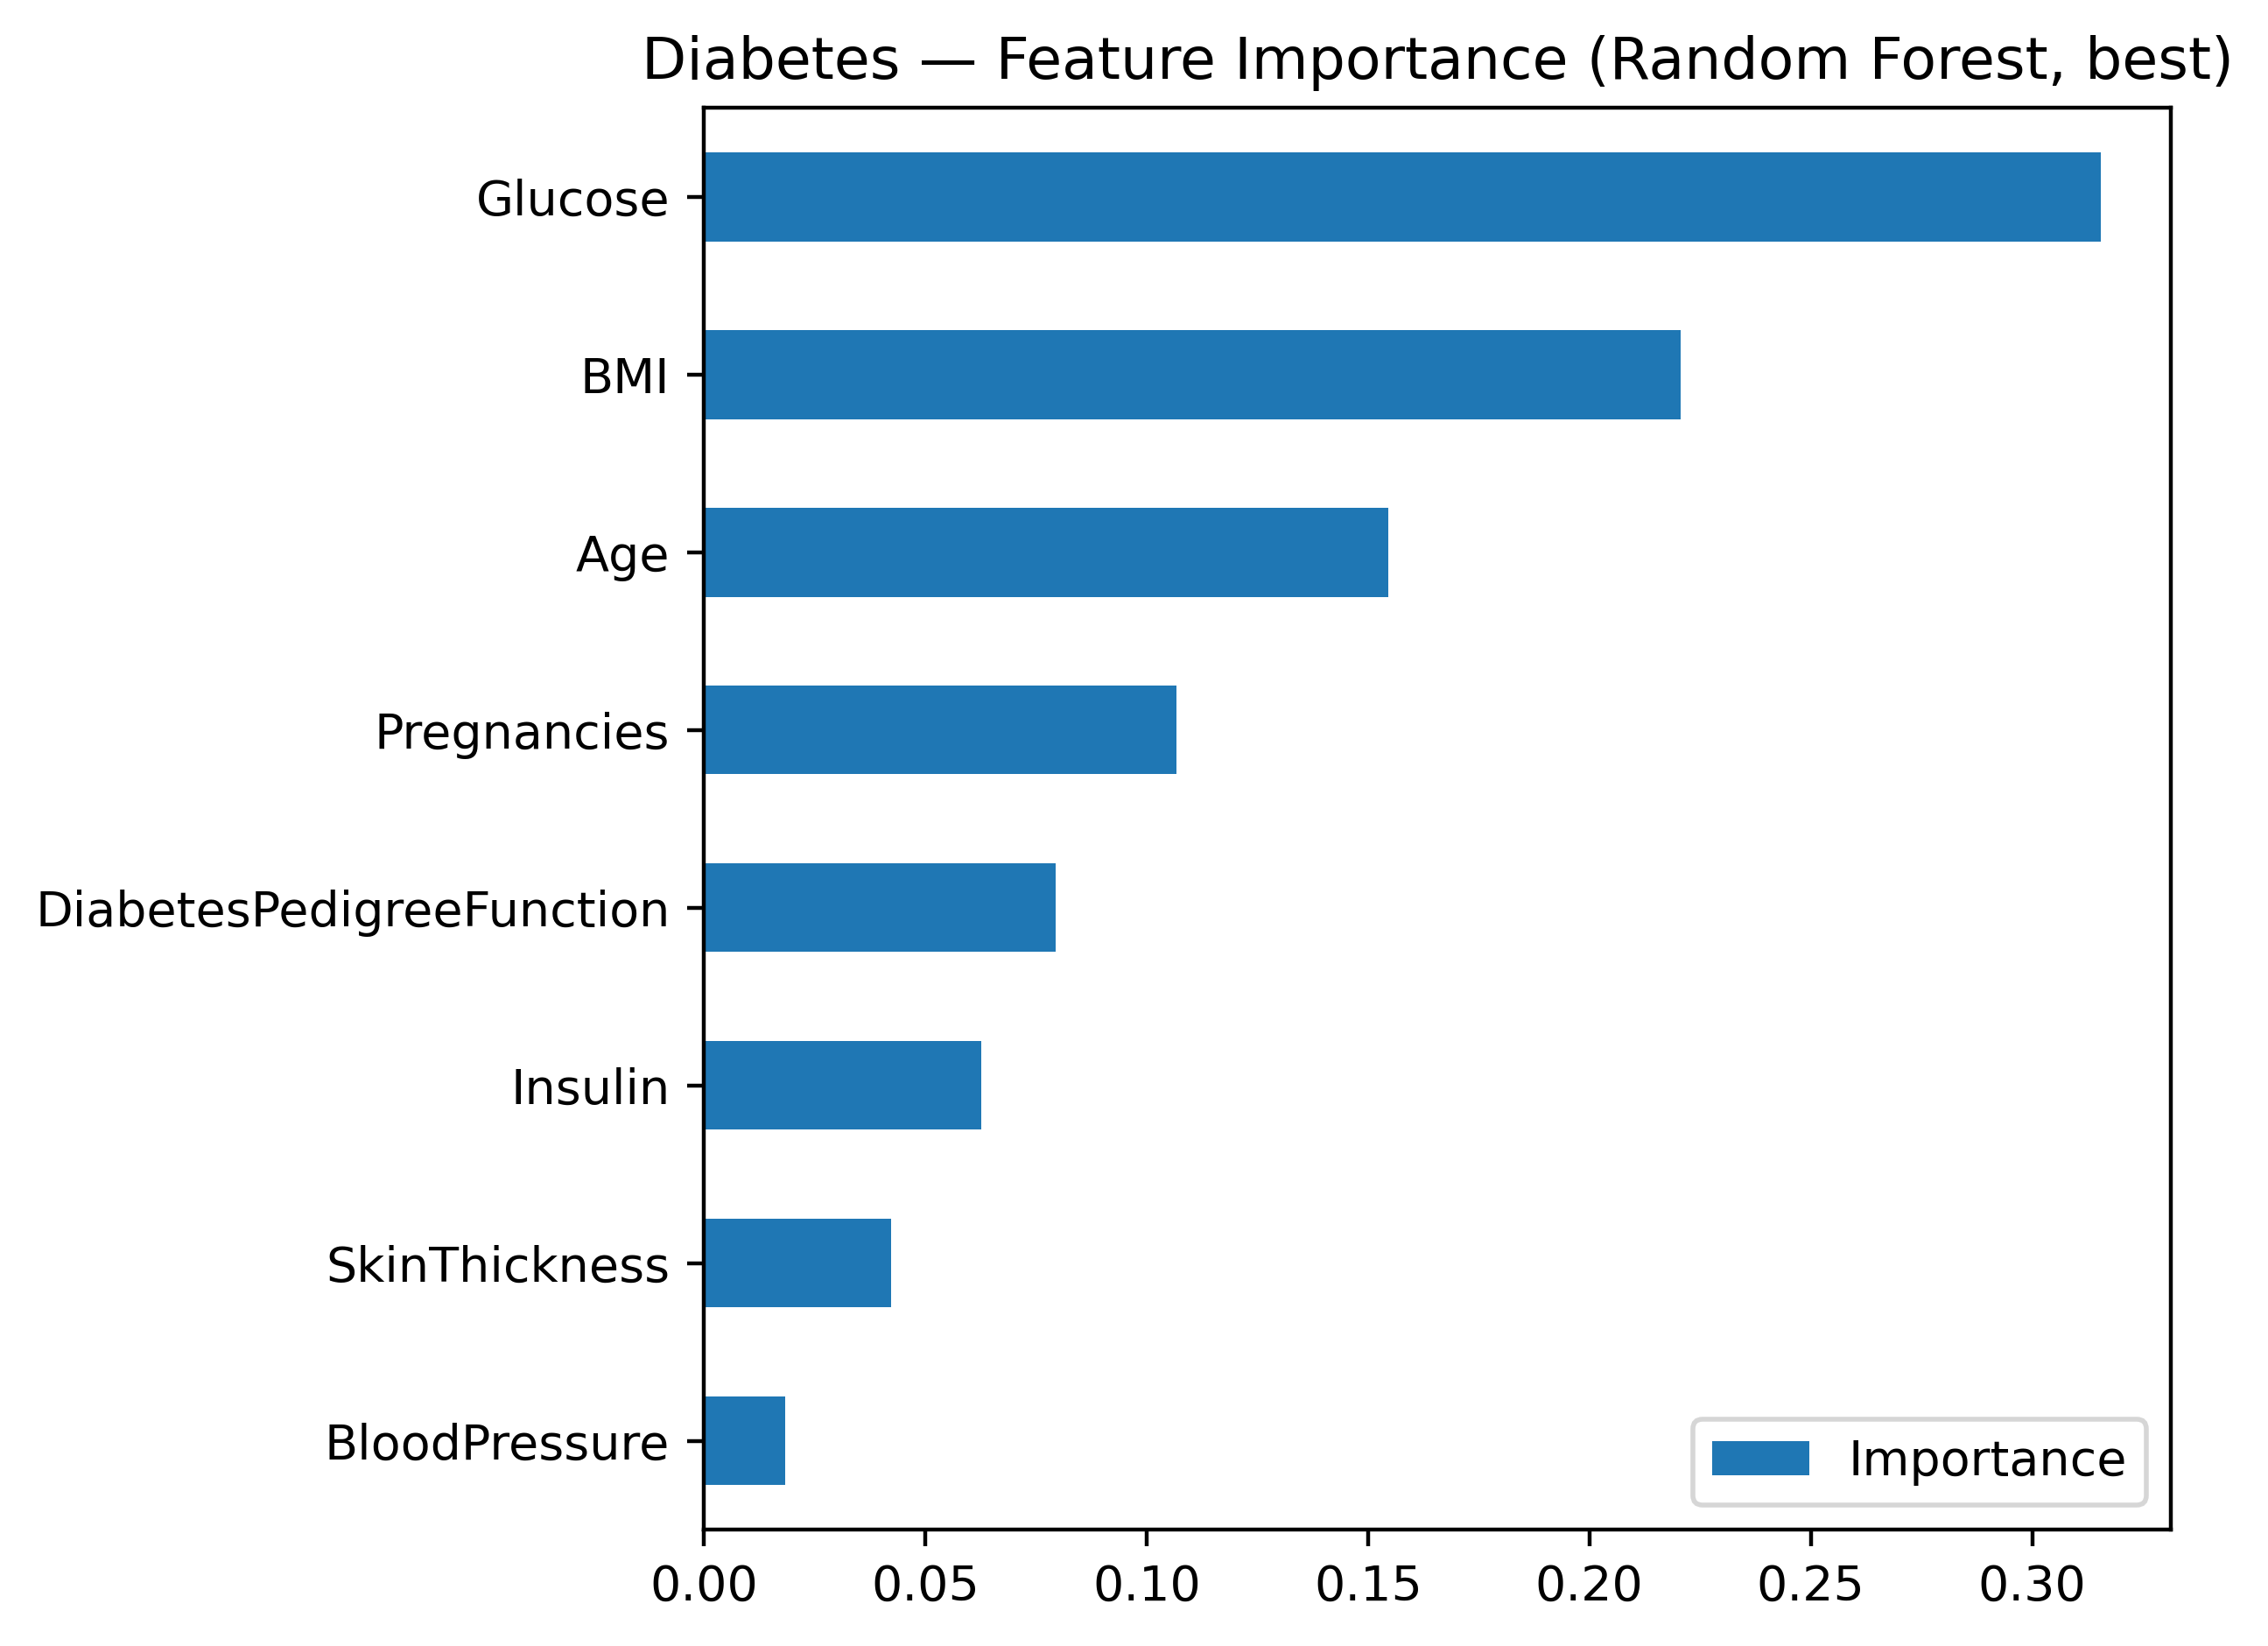

In [47]:
cv_rf_ex_db.best_params_  
feat_imp_df_db = pd.DataFrame({
    'Importance': cv_rf_ex_db.best_estimator_.feature_importances_
}, index=features_response_db[:-1])

feat_imp_df_db.sort_values('Importance', ascending=True).plot.barh()
plt.title("Diabetes — Feature Importance (Random Forest, best)")
plt.tight_layout()
plt.savefig("diabetes_rf_feature_importance.png", dpi=300)
plt.show()


# 2.2. GIẢI THUẬT 2: SUPPORT VECTOR MACHINE (SVM) 


## 2.2.2. Bài làm mẫu 


### Bài toán 1: Thực hiện các nhiệm vụ trong bài toán 1 để xây dựng mô hình với giải thuật SVM cho dữ liệu Iris-data 

#### Nhiệm vụ 1: Xây dựng mô hình SVM để phân loại các loài hoa cẩm chướng 


In [48]:

import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split

# Download & Load dữ liệu iris từ sklearn
iris = datasets.load_iris()

# Hiển thị mô tả dữ liệu
print(iris.DESCR)

# Tách ma trận đặc trưng và nhãn
data = iris.data
target = iris.target

# Chia dữ liệu huấn luyện / kiểm tra theo tỉ lệ 80:20
X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.2, random_state=101
)


.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [49]:
#  Nhiệm vụ 2: Xây dựng mô hình SVM
from sklearn import svm

# Khởi tạo mô hình phân lớp
clf = svm.SVC()

# Huấn luyện mô hình với dữ liệu train
clf.fit(X_train, y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [50]:
#  Nhiệm vụ 3: Đánh giá độ chính xác
train_acc = clf.score(X_train, y_train)
val_acc = clf.score(X_test, y_test)

print("Training accuracy: {}".format(train_acc))
print("Validation accuracy: {}".format(val_acc))


Training accuracy: 0.95
Validation accuracy: 0.9666666666666667


In [51]:
# Nhiệm vụ 4: Tìm kernel tối ưu
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_svm = None
best_val_acc = -1
best_kernel = None

# Thử các kernel và chọn mô hình tốt nhất
for i in range(4):
    clf = svm.SVC(kernel=kernels[i], probability=True)
    clf.fit(X_train, y_train)
    tmp_val_acc = clf.score(X_test, y_test)
    if tmp_val_acc > best_val_acc:
        best_val_acc = tmp_val_acc
        best_svm = clf
        best_kernel = kernels[i]

print("Best validation accuracy : {} with kernel: {}".format(best_val_acc, best_kernel))


Best validation accuracy : 1.0 with kernel: linear


### Bài toán 2: Xây dựng mô hình dựa vào giải thuật SVM trên dữ liệu hình ảnh Handwritten-Digit-MNIST SVM. 



#### Nhiệm vụ 1: Tìm hiểu về cách biểu diễn và hiển thị các ảnh từ tập dữ liệu là hình ảnh 


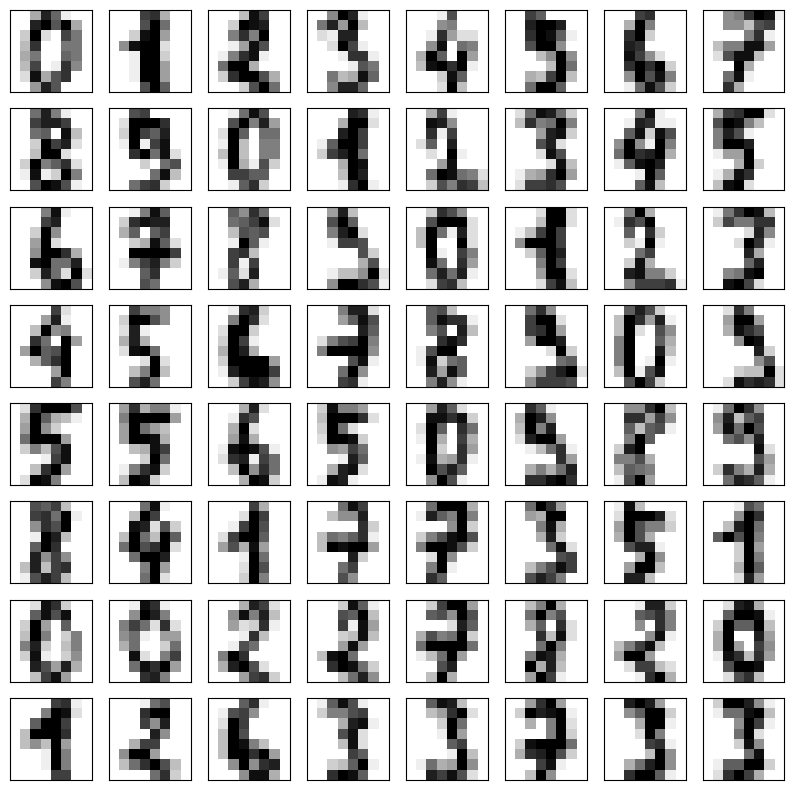

In [4]:

from sklearn.datasets import load_digits
digits = load_digits(n_class=10)
digits
digits['data'][0].reshape(8,8)
digits['data'][0]
digits['target'][0:9]
fig, ax = plt.subplots(8,8, figsize=(10,10))
for i, axi in enumerate(ax.flat):
    axi.imshow(digits.images[i], cmap='binary')
    axi.set(xticks=[], yticks=[])



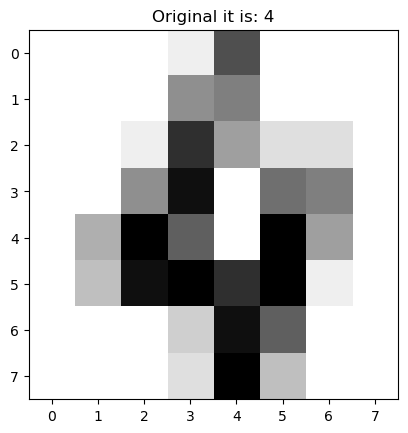

In [5]:

def view_digit(index):
    plt.imshow(digits.images[index], cmap=plt.cm.gray_r)
    plt.title('Original it is: ' + str(digits.target[index]))
    plt.show()

view_digit(4)


#### Nhiệm vụ 2: Xây dựng mô hình SVM để nhận diện chữ viết tay từ 0 – 9


<Axes: >

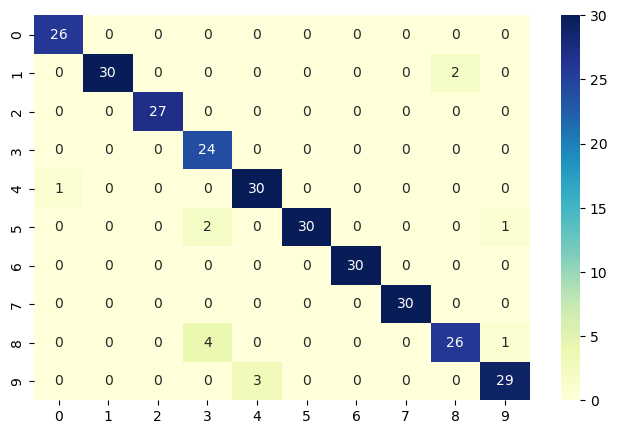

In [7]:
from sklearn import svm
main_data = digits['data']
targets = digits['target']
svc = svm.SVC(gamma=0.001, C=100)
svc.fit(main_data[:1500], targets[:1500])
predictions = svc.predict(main_data[1501:])
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(predictions, targets[1501:])
conf_matrix = pd.DataFrame(data=cm)
plt.figure(figsize=(8,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="YlGnBu")



In [8]:
from sklearn.metrics import classification_report
print(classification_report(predictions, targets[1501:]))


              precision    recall  f1-score   support

           0       0.96      1.00      0.98        26
           1       1.00      0.94      0.97        32
           2       1.00      1.00      1.00        27
           3       0.80      1.00      0.89        24
           4       0.91      0.97      0.94        31
           5       1.00      0.91      0.95        33
           6       1.00      1.00      1.00        30
           7       1.00      1.00      1.00        30
           8       0.93      0.84      0.88        31
           9       0.94      0.91      0.92        32

    accuracy                           0.95       296
   macro avg       0.95      0.96      0.95       296
weighted avg       0.96      0.95      0.95       296



## 2.2.3. Bài tập thực hành 1 Xây dựng mô hình từ giải thuật SVM trên dữ liệu bệnh tiểu đường. 

In [11]:

import pandas as pd
from pathlib import Path

DATASET_DB = "uciml/pima-indians-diabetes-database"
DATA_DIR_DB = Path("data_diabetes_svm")
TARGET_FILE_DB = Path("data_diabetes_svm.csv")

if not TARGET_FILE_DB.exists():
    DATA_DIR_DB.mkdir(parents=True, exist_ok=True)
    api.dataset_download_files(DATASET_DB, path=str(DATA_DIR_DB), unzip=True)
    src_csv = DATA_DIR_DB / "diabetes.csv"
    src_csv.rename(TARGET_FILE_DB)
else:
    print(" Đã có data_diabetes_svm.csv — bỏ qua tải.")


Dataset URL: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database


In [12]:
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv("data_diabetes_svm.csv")
X = df.drop(columns=["Outcome"]).values
y = df["Outcome"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24, stratify=y
)


In [13]:
from sklearn import svm
svc = svm.SVC(kernel="rbf", gamma="scale", C=2, probability=False, random_state=24)
svc.fit(X_train, y_train)


,C,2
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [14]:
train_acc = svc.score(X_train, y_train)
val_acc = svc.score(X_test, y_test)
print("Training accuracy:", train_acc)
print("Validation accuracy:", val_acc)


Training accuracy: 0.7801302931596091
Validation accuracy: 0.7532467532467533


<Axes: >

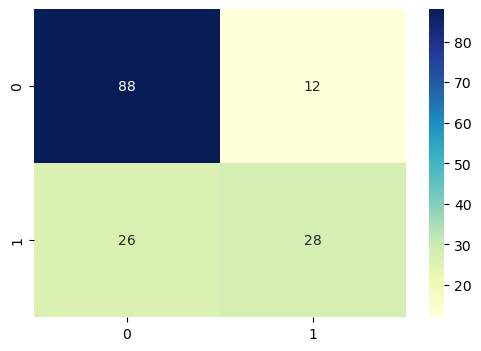

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, svc.predict(X_test))
conf_matrix = pd.DataFrame(data=cm)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="YlGnBu")


In [16]:
from sklearn.metrics import classification_report
print(classification_report(y_test, svc.predict(X_test)))


              precision    recall  f1-score   support

           0       0.77      0.88      0.82       100
           1       0.70      0.52      0.60        54

    accuracy                           0.75       154
   macro avg       0.74      0.70      0.71       154
weighted avg       0.75      0.75      0.74       154



## 2.2.4. Bài tập thực hành 2  Xây dựng mô hình từ giải thuật SVM trên dữ liệu các con thú trong rừng. 


In [17]:

DATASET_DB = "uciml/pima-indians-diabetes-database"
DATA_DIR_DB = Path("data_diabetes_svm")
TARGET_FILE_DB = Path("data_diabetes_svm.csv")

if not TARGET_FILE_DB.exists():
    DATA_DIR_DB.mkdir(parents=True, exist_ok=True)
    api.dataset_download_files(DATASET_DB, path=str(DATA_DIR_DB), unzip=True)
    src_csv = DATA_DIR_DB / "diabetes.csv"
    src_csv.rename(TARGET_FILE_DB)
else:
    print(" Đã có data_diabetes_svm.csv — bỏ qua tải.")


 Đã có data_diabetes_svm.csv — bỏ qua tải.


In [18]:

df = pd.read_csv("data_diabetes_svm.csv")
X = df.drop(columns=["Outcome"]).values
y = df["Outcome"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24, stratify=y
)


In [19]:

svc = svm.SVC(kernel="rbf", gamma="scale", C=2, probability=False, random_state=24)
svc.fit(X_train, y_train)


,C,2
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [20]:
train_acc = svc.score(X_train, y_train)
val_acc = svc.score(X_test, y_test)
print("Training accuracy:", train_acc)
print("Validation accuracy:", val_acc)


Training accuracy: 0.7801302931596091
Validation accuracy: 0.7532467532467533


              precision    recall  f1-score   support

           0       0.77      0.88      0.82       100
           1       0.70      0.52      0.60        54

    accuracy                           0.75       154
   macro avg       0.74      0.70      0.71       154
weighted avg       0.75      0.75      0.74       154



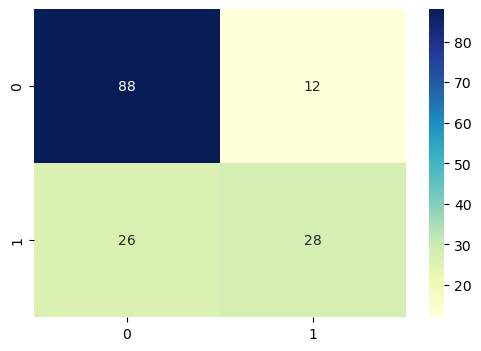

In [23]:


cm = confusion_matrix(y_test, svc.predict(X_test))
conf_matrix = pd.DataFrame(data=cm)
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="YlGnBu")
print(classification_report(y_test, svc.predict(X_test)))


# 2.3. GIẢI THUẬT 3: BAYES NGÂY THƠ (NAÏVE BAYES)

## 2.3.2. Bài làm mẫu 


### Bài toán 1: Xây dựng mô hình dữ liệu bằng giải thuật Bayes ngây thơ trên tập dữ liệu lấy tại 

#### Nhiệm vụ 1: Phân loại sử dụng Naïve Bays


In [ ]:
from pathlib import Path
import zipfile, shutil
import pandas as pd

DATASET_SPAM = "uciml/sms-spam-collection-dataset" # tác giả không cung cấp API Kaggle, dung dataset gốc thay thế,có data tương tự
DATA_DIR_SPAM = Path("data_spam")
TARGET_FILE_SPAM = Path("spam.csv")

if not TARGET_FILE_SPAM.exists():
    DATA_DIR_SPAM.mkdir(parents=True, exist_ok=True)
    api.dataset_download_files(DATASET_SPAM, path=str(DATA_DIR_SPAM))
    for z in DATA_DIR_SPAM.glob("*.zip"):
        with zipfile.ZipFile(z, "r") as zf:
            zf.extractall(DATA_DIR_SPAM)
    src_csv = next(DATA_DIR_SPAM.glob("*.csv"))
    df = pd.read_csv(src_csv, encoding="latin-1")
    for c in ['Unnamed: 2','Unnamed: 3','Unnamed: 4']:
        if c not in df.columns:
            df[c] = pd.NA
    df.to_csv(TARGET_FILE_SPAM, index=False, encoding="latin-1")
    print(" Đã tạo spam.csv từ dataset thay thế.")
else:
    print(" Đã có spam.csv — bỏ qua tải.")


✅ Đã có spam.csv — bỏ qua tải.


In [33]:
#Importing the Necessary libraries 
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split 
from sklearn.feature_extraction.text import CountVectorizer 
from sklearn.naive_bayes import MultinomialNB 
from sklearn.metrics import accuracy_score, confusion_matrix,  classification_report 
data = pd.read_csv('spam.csv', encoding='latin-1') 
#display the first 5 rows 
data.head() 


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [34]:
# Drop the columns with NaN values 
data = data.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1) 
# Rename columns for clarity: 
data.columns = ['label', 'text'] 
# Separate features (X) and target labels (y) 
X =  data.drop('label', axis=1) 
y = data['label'] 
# Split the data into training and testing sets (80% training, 20% testing) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 


In [35]:
from sklearn.feature_extraction.text import CountVectorizer 
vectorizer = CountVectorizer() 
# Fit and transform the training data (X_train) 
X_train_vectorized = vectorizer.fit_transform(X_train['text']) 
# Transform the test data (X_test) 
X_test_vectorized = vectorizer.transform(X_test['text']) 


In [36]:
from sklearn.naive_bayes import MultinomialNB 
classifier = MultinomialNB() 
classifier.fit(X_train_vectorized, y_train) 


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [37]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 
# Make predictions on the test data 
y_pred = classifier.predict(X_test_vectorized) 
# Evaluate the model 
accuracy = accuracy_score(y_test, y_pred) 
conf_matrix = confusion_matrix(y_test, y_pred) 
classification_rep = classification_report(y_test, y_pred) 
print(f"Accuracy: {accuracy:.2f}") 
print("Confusion Matrix:") 
print(conf_matrix) 
print("Classification Report:") 
print(classification_rep) 


Accuracy: 0.98
Confusion Matrix:
[[963   2]
 [ 16 134]]
Classification Report:
              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       965
        spam       0.99      0.89      0.94       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



## 2.3.3. Bài tập thực hành 1 Xây dựng mô hình Naïve ngây thơ trên tập dữ liệu hành vi của khách hàng 


In [44]:
data = pd.read_csv("customer.csv")
data.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
from sklearn.model_selection import train_test_split

data = data.dropna()

# Mã hóa cột Gender: Male=1, Female=0
data["Gender"] = data["Gender"].map({"Male": 1, "Female": 0})

X = data.drop(columns=["Purchased"])
y = data["Purchased"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=24
)


In [49]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)


,priors,None
,var_smoothing,1e-09


In [50]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = nb.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.975
Confusion matrix:
 [[52  0]
 [ 2 26]]
Classification report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98        52
           1       1.00      0.93      0.96        28

    accuracy                           0.97        80
   macro avg       0.98      0.96      0.97        80
weighted avg       0.98      0.97      0.97        80



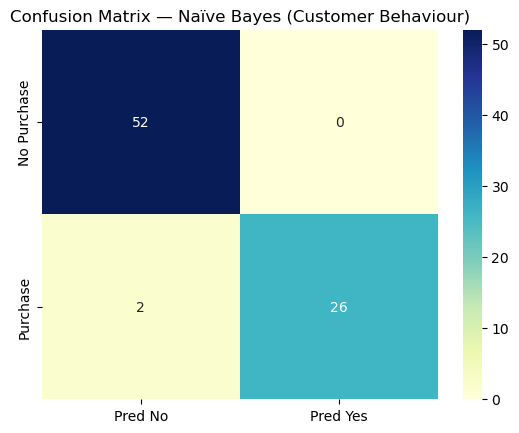

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(pd.DataFrame(cm, index=["No Purchase","Purchase"], columns=["Pred No","Pred Yes"]),
            annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix — Naïve Bayes (Customer Behaviour)")
plt.show()


## 2.3.4. Bài tập thực hành 2 Xây dựng mô hình Naïve ngây thơ trên tập dữ liệu mushroom. 


In [53]:

from pathlib import Path
import zipfile, shutil, pandas as pd

DATASET_MUSH = "uciml/mushroom-classification"
DATA_DIR_MUSH = Path("data_mushroom")
TARGET_FILE_MUSH = Path("mushrooms.csv")

if not TARGET_FILE_MUSH.exists():
    DATA_DIR_MUSH.mkdir(parents=True, exist_ok=True)
    api.dataset_download_files(DATASET_MUSH, path=str(DATA_DIR_MUSH))
    for z in DATA_DIR_MUSH.glob("*.zip"):
        with zipfile.ZipFile(z, "r") as zf:
            zf.extractall(DATA_DIR_MUSH)
    src_csv = next(DATA_DIR_MUSH.glob("*.csv"))
    shutil.copy2(src_csv, TARGET_FILE_MUSH)
    print(" Đã tạo mushrooms.csv")
else:
    print(" Đã có mushrooms.csv — bỏ qua tải.")

data = pd.read_csv("mushrooms.csv")
data.head()


 Đã có mushrooms.csv — bỏ qua tải.


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [54]:

from sklearn.preprocessing import LabelEncoder

data = data.dropna()

# Mã hóa toàn bộ cột dạng chuỗi sang số
le = LabelEncoder()
for col in data.columns:
    data[col] = le.fit_transform(data[col])

X = data.drop(columns=["class"])
y = data["class"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)


In [55]:

from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)


,priors,None
,var_smoothing,1e-09


In [56]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = nb.predict(X_test)

acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(f"Accuracy: {acc:.2f}")
print("Confusion Matrix:")
print(cm)
print("Classification Report:")
print(cr)


Accuracy: 0.92
Confusion Matrix:
[[797  72]
 [ 59 697]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       869
           1       0.91      0.92      0.91       756

    accuracy                           0.92      1625
   macro avg       0.92      0.92      0.92      1625
weighted avg       0.92      0.92      0.92      1625



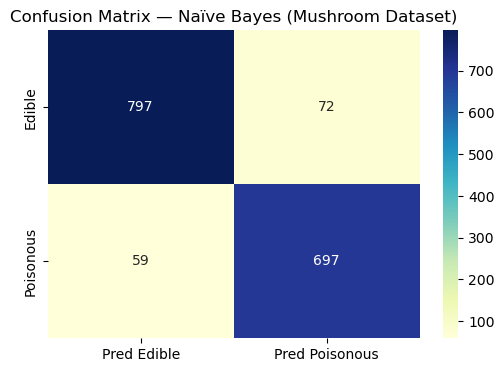

In [57]:

import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = pd.DataFrame(data=cm, index=["Edible", "Poisonous"], columns=["Pred Edible", "Pred Poisonous"])
plt.figure(figsize=(6,4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Confusion Matrix — Naïve Bayes (Mushroom Dataset)")
plt.show()
